# **Parkovich - умный сервис для поиска свободных парковочных мест**

# Исследование: "Прогнозирование занятости парковки на основе анализа временных рядов"

___

** Датасет синтезирован в другом файле

## 1. Взгляд на данные

Посмотрим, что представляет из себя датасет, чтобы далее с ним работать.

In [31]:
# Импорт основных библиотек для анализа данных
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Импорт библиотек для машинного обучения
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Импорт библиотек для работы с временными рядами
from scipy import stats
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose

# Настройка отображения графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("Библиотеки успешно загружены!")

Библиотеки успешно загружены!


### 1.1 Поверхностный взгляд на данные

In [13]:
# Загрузка датасета из Excel файла
df = pd.read_excel('Dataset.xlsx')

print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")
print(f"\nПервые 5 строк:")
display(df.head())

print(f"\nТипы данных:")
print(df.dtypes)

print(f"\nСтатистика по числовым колонкам:")
display(df.describe())

Размер датасета: 8761 строк, 23 столбцов

Первые 5 строк:


,id,date,hour,day_of_week,month,day_of_month,week_of_year,is_weekend,is_holiday,is_friday,...,temperature,weather_encoded,app_views,app_views_lag1,app_views_lag2,app_views_lag3,occupied_spots,occupancy_pct,free_spots,high_occupancy
0,0,2024-01-01 00:00:00+03:00,0,0,1,1,1,0,1,0,...,-9.6,1,1,1,1,1,100,100,0,1
1,1,2024-01-01 01:00:00+03:00,1,0,1,1,1,0,1,0,...,-10.5,1,1,1,1,1,100,100,0,1
2,2,2024-01-01 02:00:00+03:00,2,0,1,1,1,0,1,0,...,-6.6,0,1,1,1,1,100,100,0,1
3,3,2024-01-01 03:00:00+03:00,3,0,1,1,1,0,1,0,...,-17.3,3,1,1,1,1,100,100,0,1
4,4,2024-01-01 04:00:00+03:00,4,0,1,1,1,0,1,0,...,-13.2,3,1,1,1,1,100,100,0,1



Типы данных:
id                   int64
date                object
hour                 int64
day_of_week          int64
month                int64
day_of_month         int64
week_of_year         int64
is_weekend           int64
is_holiday           int64
is_friday            int64
is_monday            int64
quarter              int64
weather             object
temperature        float64
weather_encoded      int64
app_views            int64
app_views_lag1       int64
app_views_lag2       int64
app_views_lag3       int64
occupied_spots       int64
occupancy_pct        int64
free_spots           int64
high_occupancy       int64
dtype: object

Статистика по числовым колонкам:


,id,hour,day_of_week,month,day_of_month,week_of_year,is_weekend,is_holiday,is_friday,is_monday,...,temperature,weather_encoded,app_views,app_views_lag1,app_views_lag2,app_views_lag3,occupied_spots,occupancy_pct,free_spots,high_occupancy
count,8761.000000,8761.000000,8761.000000,8761.000000,8761.000000,8761.000000,8761.000000,8761.000000,8761.000000,8761.000000,...,8761.000000,8761.000000,8761.000000,8761.000000,8761.000000,8761.000000,8761.000000,8761.000000,8761.000000,8761.000000
mean,4380.000000,11.498687,2.991553,6.499258,15.716813,26.427234,0.284899,0.057642,0.142449,0.145189,...,2.401929,1.013697,16.754708,16.754594,16.754138,16.753681,70.099304,70.099304,29.900696,0.598334
std,2529.227188,6.923277,2.003518,3.444476,8.788863,15.049363,0.451392,0.233078,0.349531,0.352311,...,10.321159,1.036456,17.059023,17.059125,17.059493,17.059861,32.171557,32.171557,32.171557,0.490263
min,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,-17.300000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2190.000000,5.000000,1.000000,4.000000,8.000000,13.000000,0.000000,0.000000,0.000000,0.000000,...,-6.900000,0.000000,2.000000,2.000000,2.000000,2.000000,41.000000,41.000000,0.000000,0.000000
50%,4380.000000,11.000000,3.000000,7.000000,16.000000,26.000000,0.000000,0.000000,0.000000,0.000000,...,0.933333,1.000000,12.000000,12.000000,12.000000,12.000000,86.000000,86.000000,14.000000,1.000000
75%,6570.000000,17.000000,5.000000,9.000000,23.000000,39.000000,1.000000,0.000000,0.000000,0.000000,...,12.650000,2.000000,25.000000,25.000000,25.000000,25.000000,100.000000,100.000000,59.000000,1.000000
max,8760.000000,23.000000,6.000000,12.000000,31.000000,52.000000,1.000000,1.000000,1.000000,1.000000,...,21.000000,4.000000,127.000000,127.000000,127.000000,127.000000,100.000000,100.000000,100.000000,1.000000


### 1.2 Проверка данных на пропуски и аномалии

Хотя и сами моделировали, но на всякий случай.

In [18]:
# Проверка пропущенных значений
missing_data = df.isnull().sum()
missing_percentage = (missing_data / len(df)) * 100

missing_df = pd.DataFrame({
    'Колонка': missing_data.index,
    'Пропущено': missing_data.values,
    'Процент': missing_percentage.values
})

# Отображаем только колонки с пропусками
missing_df = missing_df[missing_df['Пропущено'] > 0]
if len(missing_df) > 0:
    display(missing_df.sort_values('Процент', ascending=False))
else:
    print("Пропущенных значений не обнаружено!")

# Проверка дубликатов
print(f"\nДУБЛИКАТЫ В ДАННЫХ")
print(f"Найдено дубликатов: {df.duplicated().sum()}")

Пропущенных значений не обнаружено!

ДУБЛИКАТЫ В ДАННЫХ
Найдено дубликатов: 0


### 1.3 Визуализация распределения основных показателей

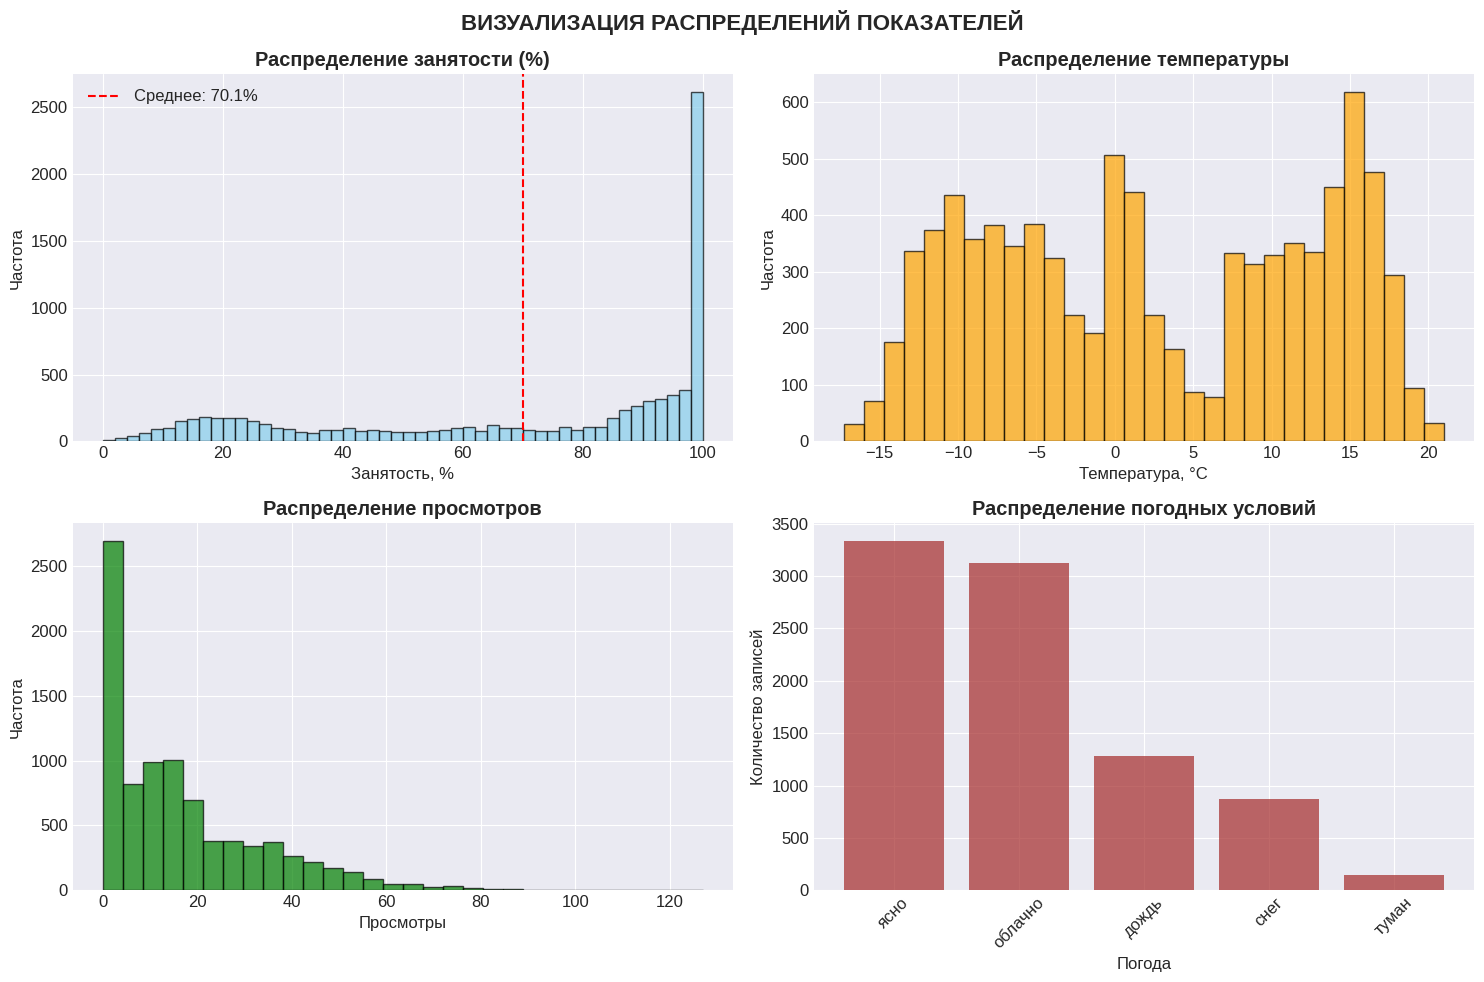


ДОПОЛНИТЕЛЬНЫЕ ГРАФИКИ:


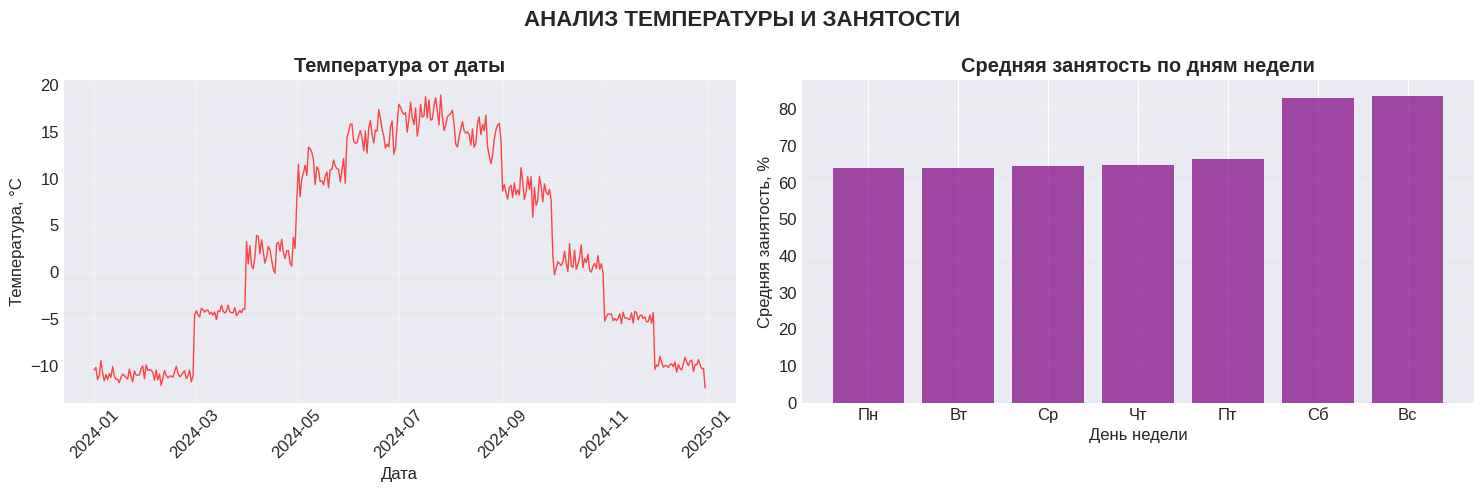

In [25]:
# Создаем subplot для визуализации распределений
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Распределение занятости
if 'occupancy_pct' in df.columns:
    axes[0, 0].hist(df['occupancy_pct'].dropna(), bins=50, alpha=0.7, color='skyblue', edgecolor='black')
    axes[0, 0].set_title('Распределение занятости (%)', fontweight='bold')
    axes[0, 0].set_xlabel('Занятость, %')
    axes[0, 0].set_ylabel('Частота')
    mean_occ = df['occupancy_pct'].mean()
    axes[0, 0].axvline(mean_occ, color='red', linestyle='--', label=f'Среднее: {mean_occ:.1f}%')
    axes[0, 0].legend()

# 2. Распределение температуры
if 'temperature' in df.columns:
    axes[0, 1].hist(df['temperature'].dropna(), bins=30, alpha=0.7, color='orange', edgecolor='black')
    axes[0, 1].set_title('Распределение температуры', fontweight='bold')
    axes[0, 1].set_xlabel('Температура, °C')
    axes[0, 1].set_ylabel('Частота')

# 3. Распределение просмотров в приложении
if 'app_views' in df.columns:
    axes[1, 0].hist(df['app_views'].dropna(), bins=30, alpha=0.7, color='green', edgecolor='black')
    axes[1, 0].set_title('Распределение просмотров', fontweight='bold')
    axes[1, 0].set_xlabel('Просмотры')
    axes[1, 0].set_ylabel('Частота')

# 4. Распределение погоды
if 'weather' in df.columns:
    weather_counts = df['weather'].value_counts()
    axes[1, 1].bar(weather_counts.index, weather_counts.values, alpha=0.7, color='brown')
    axes[1, 1].set_title('Распределение погодных условий', fontweight='bold')
    axes[1, 1].set_xlabel('Погода')
    axes[1, 1].set_ylabel('Количество записей')
    axes[1, 1].tick_params(axis='x', rotation=45)

plt.suptitle('ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЙ ПОКАЗАТЕЛЕЙ', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Дополнительные графики
print("\nДОПОЛНИТЕЛЬНЫЕ ГРАФИКИ:")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Температура от даты
if 'date' in df.columns:
    # Преобразуем date в datetime если нужно
    if not pd.api.types.is_datetime64_any_dtype(df['date']):
        df['date'] = pd.to_datetime(df['date'])

    # Группируем по дате и вычисляем среднюю температуру
    daily_temp = df.groupby(df['date'].dt.date)['temperature'].mean()

    # Преобразуем индекс обратно в datetime для отображения
    daily_temp.index = pd.to_datetime(daily_temp.index)

    axes[0].plot(daily_temp.index, daily_temp.values, linewidth=1, alpha=0.7, color='red')
    axes[0].set_title('Температура от даты', fontweight='bold')
    axes[0].set_xlabel('Дата')
    axes[0].set_ylabel('Температура, °C')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(True, alpha=0.3)

# 2. Средняя занятость по дням недели
if 'day_of_week' in df.columns and 'occupancy_pct' in df.columns:
    # Приводим к целым числам
    df['day_of_week_int'] = df['day_of_week'].astype(int)
    day_occupancy = df.groupby('day_of_week_int')['occupancy_pct'].mean()

    day_names = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']

    axes[1].bar(day_names, day_occupancy.values, alpha=0.7, color='purple')
    axes[1].set_title('Средняя занятость по дням недели', fontweight='bold')
    axes[1].set_xlabel('День недели')
    axes[1].set_ylabel('Средняя занятость, %')
    axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('АНАЛИЗ ТЕМПЕРАТУРЫ И ЗАНЯТОСТИ', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Удаляем временные колонки
if 'day_of_week_int' in df.columns:
    df.drop('day_of_week_int', axis=1, inplace=True)

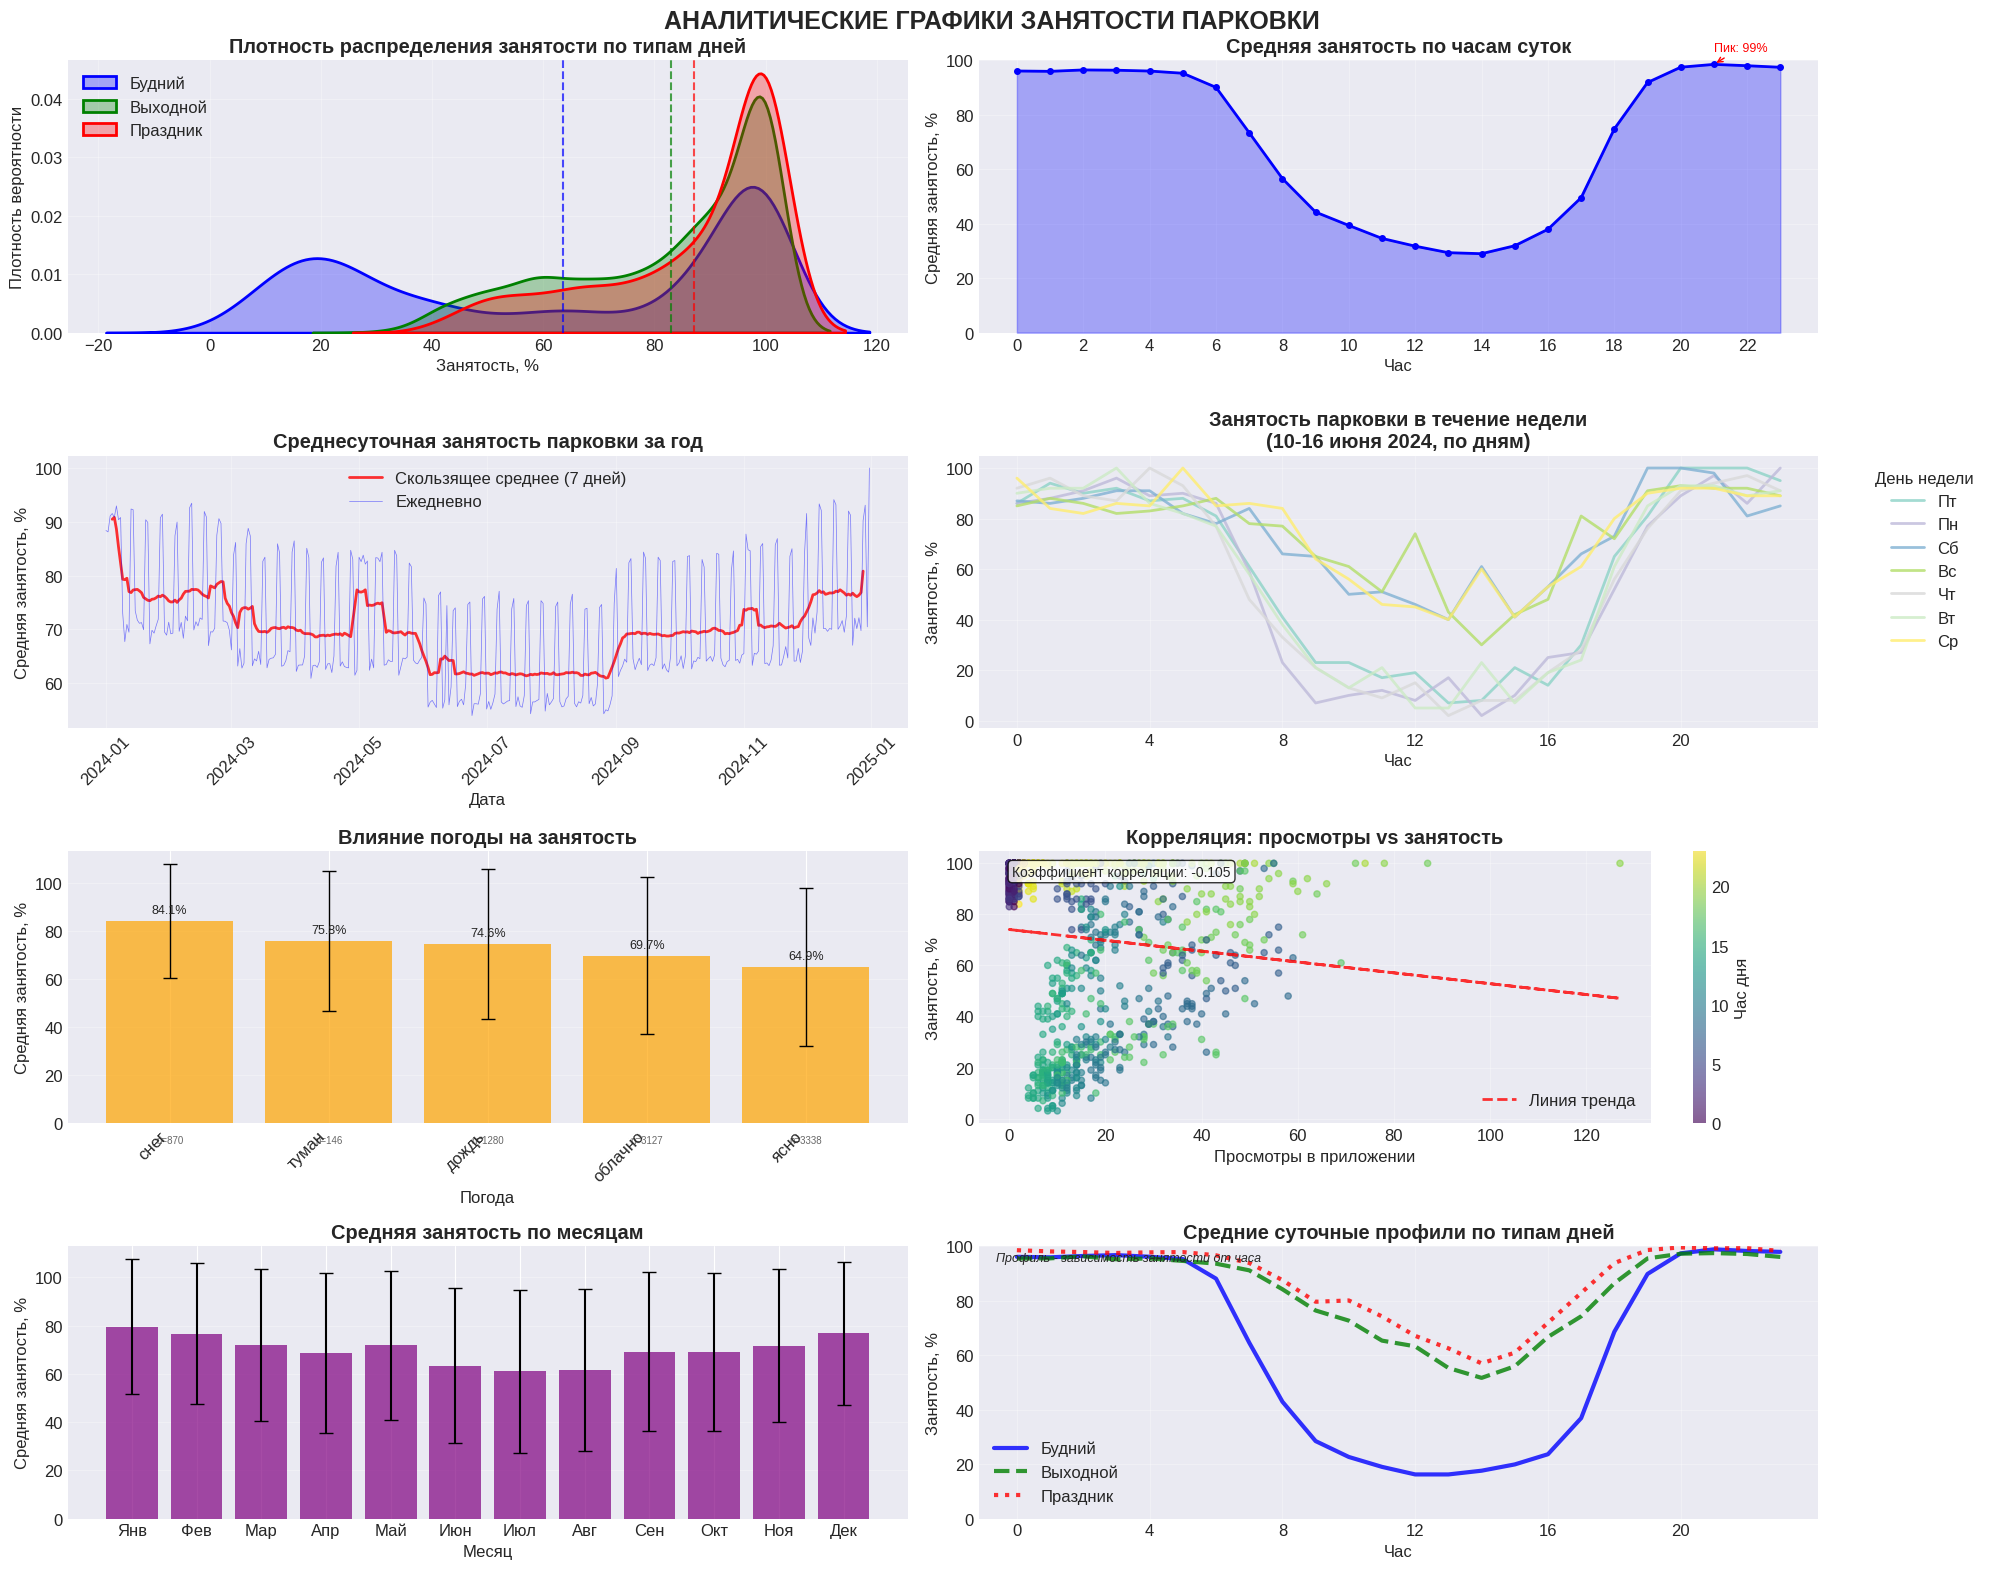

In [26]:
# Создаем фигуру с 4 строками по 2 графика (итого 8 графиков + 1 отдельный)
fig, axes = plt.subplots(4, 2, figsize=(20, 16))
axes = axes.flatten()

plot_idx = 0

# 1. Плотность распределения занятости по типам дней (сглаженная)
if 'is_holiday' in df.columns and 'is_weekend' in df.columns and 'occupancy_pct' in df.columns:
    # Создаем колонку с типом дня
    day_types = []
    for idx, row in df.iterrows():
        if row['is_holiday'] == 1:
            day_types.append('Праздник')
        elif row['is_weekend'] == 1:
            day_types.append('Выходной')
        else:
            day_types.append('Будний')

    temp_df = df.copy()
    temp_df['day_type'] = day_types

    # Строим сглаженные графики плотности (KDE)
    import seaborn as sns

    day_order = ['Будний', 'Выходной', 'Праздник']
    colors = ['blue', 'green', 'red']

    for i, day_type in enumerate(day_order):
        day_data = temp_df[temp_df['day_type'] == day_type]['occupancy_pct'].dropna()
        if len(day_data) > 10:  # Минимум 10 точек для KDE
            sns.kdeplot(day_data, ax=axes[plot_idx], label=day_type, color=colors[i],
                       linewidth=2, fill=True, alpha=0.3)

    axes[plot_idx].set_title('Плотность распределения занятости по типам дней', fontweight='bold')
    axes[plot_idx].set_xlabel('Занятость, %')
    axes[plot_idx].set_ylabel('Плотность вероятности')
    axes[plot_idx].legend()
    axes[plot_idx].grid(True, alpha=0.3)

    # Добавляем вертикальные линии для средних значений
    for i, day_type in enumerate(day_order):
        day_data = temp_df[temp_df['day_type'] == day_type]['occupancy_pct'].dropna()
        if len(day_data) > 0:
            mean_val = day_data.mean()
            axes[plot_idx].axvline(mean_val, color=colors[i], linestyle='--', alpha=0.7,
                                 label=f'{day_type} среднее: {mean_val:.1f}%')

    plot_idx += 1

# 2. Средняя занятость по часам суток
if 'hour' in df.columns and 'occupancy_pct' in df.columns:
    df['hour_int'] = df['hour'].astype(int)
    hour_occupancy = df.groupby('hour_int')['occupancy_pct'].mean()

    axes[plot_idx].plot(hour_occupancy.index, hour_occupancy.values, marker='o',
                       linewidth=2, color='blue', markersize=4)
    axes[plot_idx].fill_between(hour_occupancy.index, hour_occupancy.values,
                               alpha=0.3, color='blue')

    # Добавляем аннотации для пиковых часов
    peak_hour = hour_occupancy.idxmax()
    min_hour = hour_occupancy.idxmin()

    axes[plot_idx].annotate(f'Пик: {hour_occupancy[peak_hour]:.0f}%',
                           xy=(peak_hour, hour_occupancy[peak_hour]),
                           xytext=(peak_hour, hour_occupancy[peak_hour] + 5),
                           arrowprops=dict(arrowstyle='->', color='red'),
                           fontsize=9, color='red')

    axes[plot_idx].set_title('Средняя занятость по часам суток', fontweight='bold')
    axes[plot_idx].set_xlabel('Час')
    axes[plot_idx].set_ylabel('Средняя занятость, %')
    axes[plot_idx].set_xticks(range(0, 24, 2))
    axes[plot_idx].set_ylim(0, 100)
    axes[plot_idx].grid(True, alpha=0.3)
    plot_idx += 1

# 3. Среднесуточная занятость парковки за год
if 'date' in df.columns and 'occupancy_pct' in df.columns:
    # Группируем по дате
    if not pd.api.types.is_datetime64_any_dtype(df['date']):
        df['date'] = pd.to_datetime(df['date'])

    daily_occupancy = df.groupby(df['date'].dt.date)['occupancy_pct'].mean()
    daily_occupancy.index = pd.to_datetime(daily_occupancy.index)

    # Добавляем скользящее среднее для сглаживания
    window_size = 7  # 7 дней
    if len(daily_occupancy) > window_size:
        smooth_occupancy = daily_occupancy.rolling(window=window_size, center=True).mean()
        axes[plot_idx].plot(daily_occupancy.index, smooth_occupancy,
                           linewidth=2, color='red', alpha=0.8, label='Скользящее среднее (7 дней)')

    axes[plot_idx].plot(daily_occupancy.index, daily_occupancy.values,
                       linewidth=0.5, alpha=0.5, color='blue', label='Ежедневно')
    axes[plot_idx].set_title('Среднесуточная занятость парковки за год', fontweight='bold')
    axes[plot_idx].set_xlabel('Дата')
    axes[plot_idx].set_ylabel('Средняя занятость, %')
    axes[plot_idx].tick_params(axis='x', rotation=45)
    axes[plot_idx].grid(True, alpha=0.3)
    axes[plot_idx].legend()
    plot_idx += 1

# 4. Занятость парковки в течение недели (10-16 июня 2024)
try:
    # Фильтруем данные за указанную неделю
    week_start = pd.Timestamp('2024-06-10 00:00:00+03:00')
    week_end = pd.Timestamp('2024-06-17 00:00:00+03:00')

    week_mask = (df['date'] >= week_start) & (df['date'] <= week_end)
    week_data = df[week_mask].copy()

    if len(week_data) > 0:
        # Группируем по часам для каждого дня
        week_data['hour'] = week_data['date'].dt.hour
        week_data['day_name'] = week_data['date'].dt.day_name()

        # Для визуализации - строим несколько линий по дням
        day_names_russian = {
            'Monday': 'Пн', 'Tuesday': 'Вт', 'Wednesday': 'Ср',
            'Thursday': 'Чт', 'Friday': 'Пт', 'Saturday': 'Сб', 'Sunday': 'Вс'
        }

        colors_week = plt.cm.Set3(np.linspace(0, 1, 7))

        for i, (day_name, day_data) in enumerate(week_data.groupby('day_name')):
            day_hourly = day_data.groupby('hour')['occupancy_pct'].mean()
            rus_day = day_names_russian.get(day_name, day_name)
            axes[plot_idx].plot(day_hourly.index, day_hourly.values,
                              label=rus_day, color=colors_week[i], linewidth=2, alpha=0.8)

        axes[plot_idx].set_title('Занятость парковки в течение недели\n(10-16 июня 2024, по дням)', fontweight='bold')
        axes[plot_idx].set_xlabel('Час')
        axes[plot_idx].set_ylabel('Занятость, %')
        axes[plot_idx].set_xticks(range(0, 24, 4))
        axes[plot_idx].legend(title='День недели', bbox_to_anchor=(1.05, 1), loc='upper left')
        axes[plot_idx].grid(True, alpha=0.3)
    else:
        axes[plot_idx].text(0.5, 0.5, 'Нет данных за указанную неделю',
                           ha='center', va='center', transform=axes[plot_idx].transAxes)
        axes[plot_idx].set_title('Занятость за неделю', fontweight='bold')

    plot_idx += 1
except Exception as e:
    print(f"Ошибка при построении графика недели: {e}")
    axes[plot_idx].axis('off')
    plot_idx += 1

# 5. Влияние погоды на занятость
if 'weather' in df.columns and 'occupancy_pct' in df.columns:
    weather_occupancy = df.groupby('weather')['occupancy_pct'].agg(['mean', 'std', 'count']).sort_values('mean', ascending=False)

    # Создаем барплот с доверительными интервалами
    x_pos = np.arange(len(weather_occupancy))
    bars = axes[plot_idx].bar(x_pos, weather_occupancy['mean'], alpha=0.7, color='orange',
                             yerr=weather_occupancy['std'], capsize=5, error_kw={'elinewidth': 1})

    # Добавляем значения над столбцами
    for i, (idx, row) in enumerate(weather_occupancy.iterrows()):
        axes[plot_idx].text(i, row['mean'] + 2, f"{row['mean']:.1f}%",
                           ha='center', va='bottom', fontsize=9)
        # Добавляем количество дней маленьким шрифтом
        axes[plot_idx].text(i, -5, f"n={int(row['count'])}",
                           ha='center', va='top', fontsize=7, alpha=0.7)

    axes[plot_idx].set_title('Влияние погоды на занятость', fontweight='bold')
    axes[plot_idx].set_xlabel('Погода')
    axes[plot_idx].set_ylabel('Средняя занятость, %')
    axes[plot_idx].set_xticks(x_pos)
    axes[plot_idx].set_xticklabels(weather_occupancy.index, rotation=45, ha='right')
    axes[plot_idx].grid(True, alpha=0.3, axis='y')
    plot_idx += 1

# 6. Корреляция: просмотры vs занятость
if 'app_views' in df.columns and 'occupancy_pct' in df.columns:
    # Берем выборку для лучшей визуализации
    sample_size = min(1000, len(df))
    sample = df.sample(sample_size, random_state=42)

    # Цветовая кодировка по часам
    scatter = axes[plot_idx].scatter(sample['app_views'], sample['occupancy_pct'],
                                    c=sample['hour'], cmap='viridis', alpha=0.6, s=20)

    axes[plot_idx].set_title('Корреляция: просмотры vs занятость', fontweight='bold')
    axes[plot_idx].set_xlabel('Просмотры в приложении')
    axes[plot_idx].set_ylabel('Занятость, %')
    axes[plot_idx].grid(True, alpha=0.3)

    # Цветовая шкала для часов
    cbar = plt.colorbar(scatter, ax=axes[plot_idx])
    cbar.set_label('Час дня')

    # Линия тренда
    if len(sample) > 1:
        try:
            z = np.polyfit(sample['app_views'], sample['occupancy_pct'], 1)
            p = np.poly1d(z)
            axes[plot_idx].plot(sample['app_views'], p(sample['app_views']),
                               "r--", linewidth=2, alpha=0.8, label='Линия тренда')

            # Вычисляем коэффициент корреляции
            correlation = sample['app_views'].corr(sample['occupancy_pct'])
            axes[plot_idx].text(0.05, 0.95, f'Коэффициент корреляции: {correlation:.3f}',
                               transform=axes[plot_idx].transAxes, fontsize=10,
                               verticalalignment='top',
                               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
            axes[plot_idx].legend()
        except Exception as e:
            print(f"Ошибка при построении линии тренда: {e}")

    plot_idx += 1

# 7. Средняя занятость по месяцам
if 'date' in df.columns and 'occupancy_pct' in df.columns:
    # Извлекаем месяц из даты
    if not pd.api.types.is_datetime64_any_dtype(df['date']):
        df['date'] = pd.to_datetime(df['date'])

    df['month'] = df['date'].dt.month
    monthly_occupancy = df.groupby('month')['occupancy_pct'].agg(['mean', 'std', 'count'])

    month_names = ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн',
                  'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек']

    # Оставляем только существующие месяцы
    existing_months = monthly_occupancy.index.astype(int)
    month_labels = [month_names[i-1] for i in existing_months if 1 <= i <= 12]

    axes[plot_idx].bar(range(len(existing_months)), monthly_occupancy['mean'],
                      yerr=monthly_occupancy['std'], capsize=5, alpha=0.7, color='purple')

    axes[plot_idx].set_title('Средняя занятость по месяцам', fontweight='bold')
    axes[plot_idx].set_xlabel('Месяц')
    axes[plot_idx].set_ylabel('Средняя занятость, %')
    axes[plot_idx].set_xticks(range(len(existing_months)))
    axes[plot_idx].set_xticklabels(month_labels)
    axes[plot_idx].grid(True, alpha=0.3, axis='y')
    plot_idx += 1

# 8. Средние суточные профили выходных дней и праздников
if 'is_weekend' in df.columns and 'is_holiday' in df.columns and 'hour' in df.columns and 'occupancy_pct' in df.columns:
    # Создаем категорию дня
    df['day_category'] = 'Будний'
    df.loc[df['is_weekend'] == 1, 'day_category'] = 'Выходной'
    df.loc[df['is_holiday'] == 1, 'day_category'] = 'Праздник'

    # Группируем по категории дня и часу
    profile_data = df.groupby(['day_category', 'hour'])['occupancy_pct'].mean().reset_index()

    categories = ['Будний', 'Выходной', 'Праздник']
    colors_category = ['blue', 'green', 'red']
    line_styles = ['-', '--', ':']

    for i, category in enumerate(categories):
        cat_profile = profile_data[profile_data['day_category'] == category]
        if len(cat_profile) > 0:
            axes[plot_idx].plot(cat_profile['hour'], cat_profile['occupancy_pct'],
                              label=category, color=colors_category[i],
                              linewidth=3, linestyle=line_styles[i], alpha=0.8)

    axes[plot_idx].set_title('Средние суточные профили по типам дней', fontweight='bold')
    axes[plot_idx].set_xlabel('Час')
    axes[plot_idx].set_ylabel('Занятость, %')
    axes[plot_idx].set_xticks(range(0, 24, 4))
    axes[plot_idx].set_ylim(0, 100)
    axes[plot_idx].legend()
    axes[plot_idx].grid(True, alpha=0.3)

    # Добавляем аннотации
    axes[plot_idx].text(0.02, 0.98, 'Профиль - зависимость занятости от часа',
                       transform=axes[plot_idx].transAxes, fontsize=9, style='italic',
                       verticalalignment='top')
    plot_idx += 1

# Выключаем неиспользуемые оси (если остались)
for i in range(plot_idx, len(axes)):
    axes[i].axis('off')

plt.suptitle('АНАЛИТИЧЕСКИЕ ГРАФИКИ ЗАНЯТОСТИ ПАРКОВКИ', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

# Удаляем временные колонки
temporary_cols = ['hour_int', 'day_category', 'month']
for col in temporary_cols:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)

КОРРЕЛЯЦИОННЫЙ АНАЛИЗ


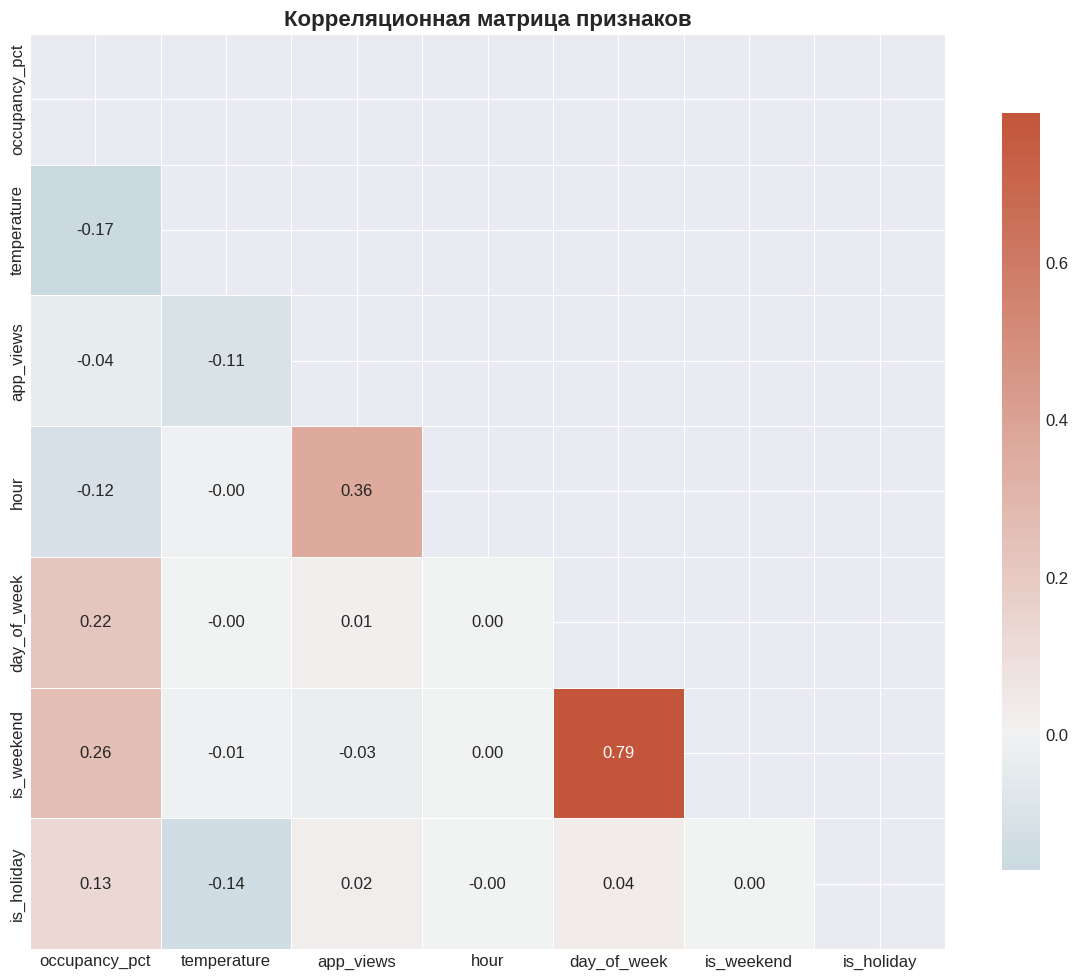


КОРРЕЛЯЦИИ С ЗАНЯТОСТЬЮ:
  • is_weekend: 0.262 (корреляция отсутствует)
  • day_of_week: 0.220 (корреляция отсутствует)
  • is_holiday: 0.131 (корреляция отсутствует)
  • app_views: -0.040 (корреляция отсутствует)
  • hour: -0.116 (корреляция отсутствует)
  • temperature: -0.172 (корреляция отсутствует)


In [28]:
print("КОРРЕЛЯЦИОННЫЙ АНАЛИЗ")
print("=" * 60)

# Выбираем числовые колонки для корреляционного анализа
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Исключаем колонки, которые не имеют смысла для корреляции (например, кодированные категории)
# Оставляем только интересующие нас показатели
important_cols = ['occupancy_pct', 'temperature', 'app_views', 'hour',
                  'day_of_week', 'is_weekend', 'is_holiday']

# Фильтруем только те, которые есть в данных
corr_cols = [col for col in important_cols if col in df.columns]

# Создаем корреляционную матрицу
correlation_matrix = df[corr_cols].corr()

# Визуализация корреляционной матрицы
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(correlation_matrix, mask=mask, cmap=cmap, annot=True, fmt='.2f',
           center=0, square=True, linewidths=.5, cbar_kws={"shrink": .8})

plt.title('Корреляционная матрица признаков', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Анализ корреляций с занятостью
print("\nКОРРЕЛЯЦИИ С ЗАНЯТОСТЬЮ:")
occupancy_correlations = correlation_matrix['occupancy_pct'].sort_values(ascending=False)
for feature, corr in occupancy_correlations.items():
    if feature != 'occupancy_pct':
        if abs(corr) > 0.3:
            strength = "сильная" if abs(corr) > 0.7 else "умеренная" if abs(corr) > 0.5 else "слабая"
            direction = "положительная" if corr > 0 else "отрицательная"
            print(f"  • {feature}: {corr:.3f} ({strength} {direction} корреляция)")
        else:
            print(f"  • {feature}: {corr:.3f} (корреляция отсутствует)")

## 2. Кластеризация временных рядов

Один временной ряд - это промежуток времени от 0 до 23 часов в сутках. То есть 1 ряд = сутки.

КЛАСТЕРИЗАЦИЯ ВРЕМЕННЫХ РЯДОВ ЗАНЯТОСТИ
Инициализация кластеризатора временных рядов...
Создание матрицы дневных профилей...
Создано 365 дневных профилей
Размерность матрицы: 365 дней × 24 часа

ШАГ 1: ОПРЕДЕЛЕНИЕ ОПТИМАЛЬНОГО ЧИСЛА КЛАСТЕРОВ
Данные подготовлены для кластеризации
Форма данных: (365, 24)

ОПРЕДЕЛЕНИЕ ОПТИМАЛЬНОГО ЧИСЛА КЛАСТЕРОВ
----------------------------------------
Тестируем 2 кластеров... Silhouette: 0.399, DB: 1.124
Тестируем 3 кластеров... Silhouette: 0.398, DB: 1.134
Тестируем 4 кластеров... Silhouette: 0.420, DB: 1.096
Тестируем 5 кластеров... Silhouette: 0.266, DB: 1.286
Тестируем 6 кластеров... Silhouette: 0.210, DB: 1.505
Тестируем 7 кластеров... Silhouette: 0.195, DB: 1.707
Тестируем 8 кластеров... Silhouette: 0.185, DB: 1.921
Тестируем 9 кластеров... Silhouette: 0.178, DB: 2.025
Тестируем 10 кластеров... Silhouette: 0.143, DB: 2.164


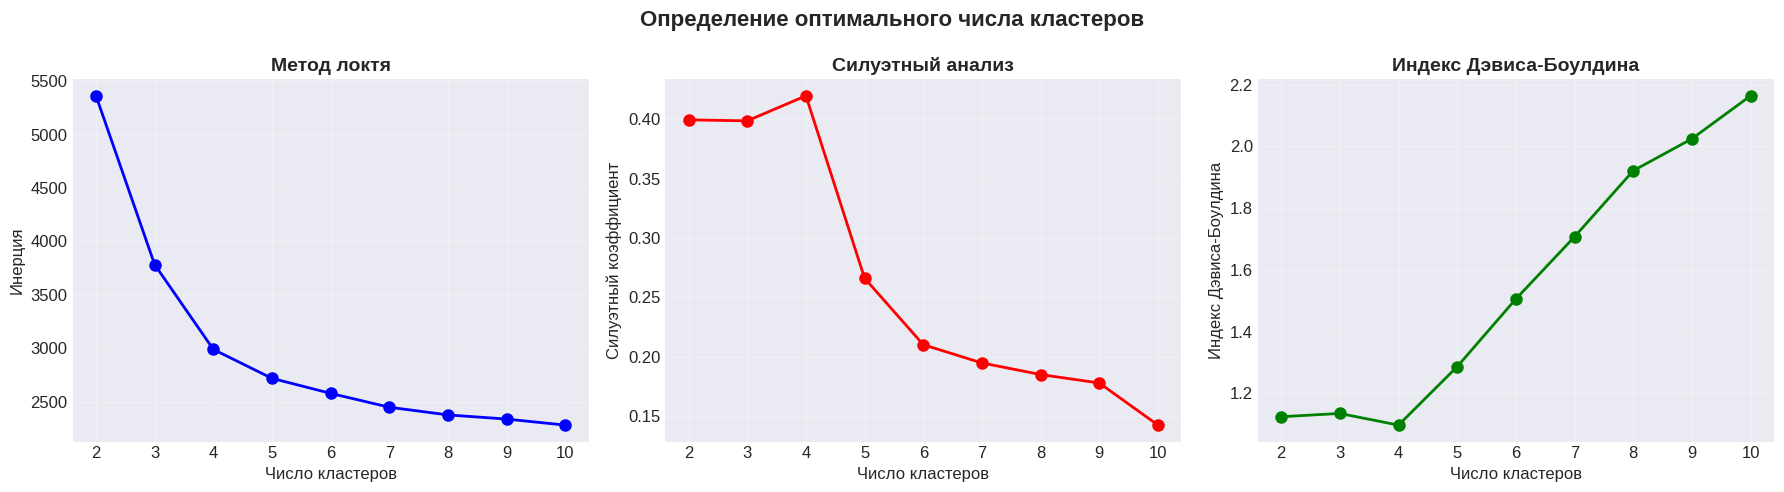


РЕКОМЕНДАЦИИ:
1. По силуэтному коэффициенту: 4 кластеров (score: 0.420)
2. По методу локтя: 7 кластеров

ШАГ 2: ВЫПОЛНЕНИЕ КЛАСТЕРИЗАЦИИ

ВЫПОЛНЕНИЕ КЛАСТЕРИЗАЦИИ С 4 КЛАСТЕРАМИ
----------------------------------------
Силуэтный коэффициент: 0.420
Индекс Дэвиса-Боулдина: 1.096
Инерция: 2990.42

СТАТИСТИКА КЛАСТЕРОВ:
  • Кластер 0: 63 дней (17.3%)
  • Кластер 1: 183 дней (50.1%)
  • Кластер 2: 91 дней (24.9%)
  • Кластер 3: 28 дней (7.7%)

ШАГ 3: ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ

ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ КЛАСТЕРИЗАЦИИ
----------------------------------------

1. ЦЕНТРОИДЫ КЛАСТЕРОВ:


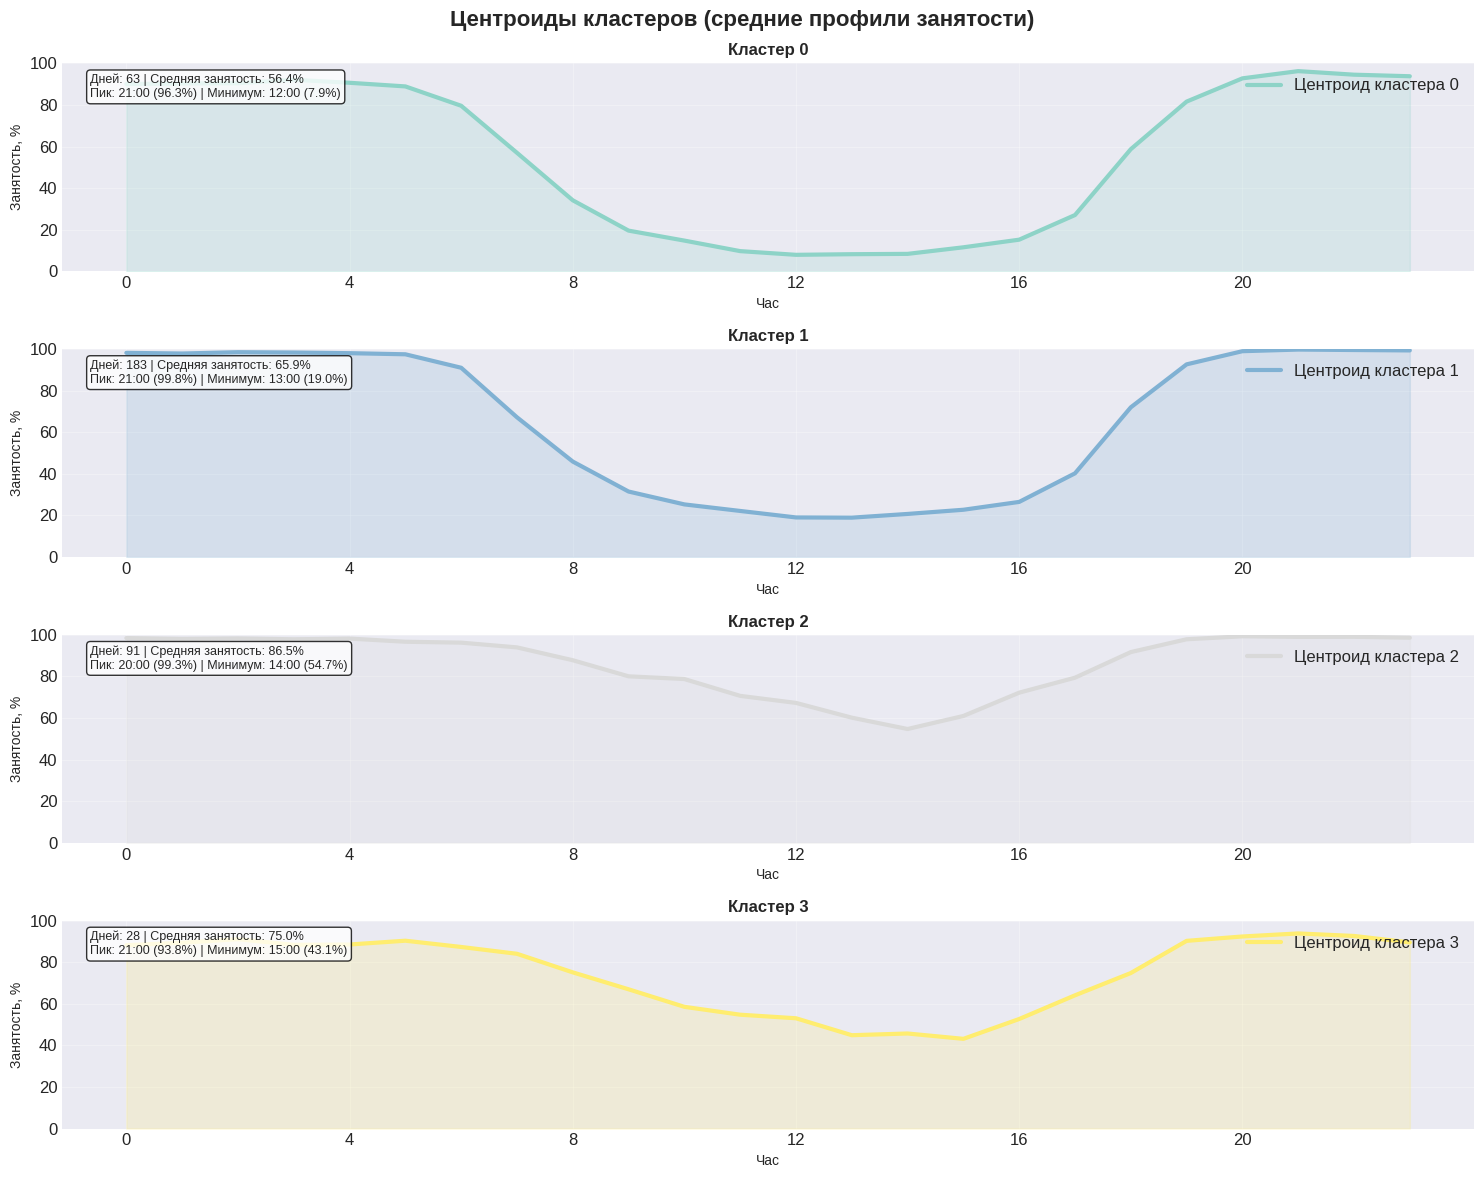


2. ВИЗУАЛИЗАЦИЯ В 2D (PCA):


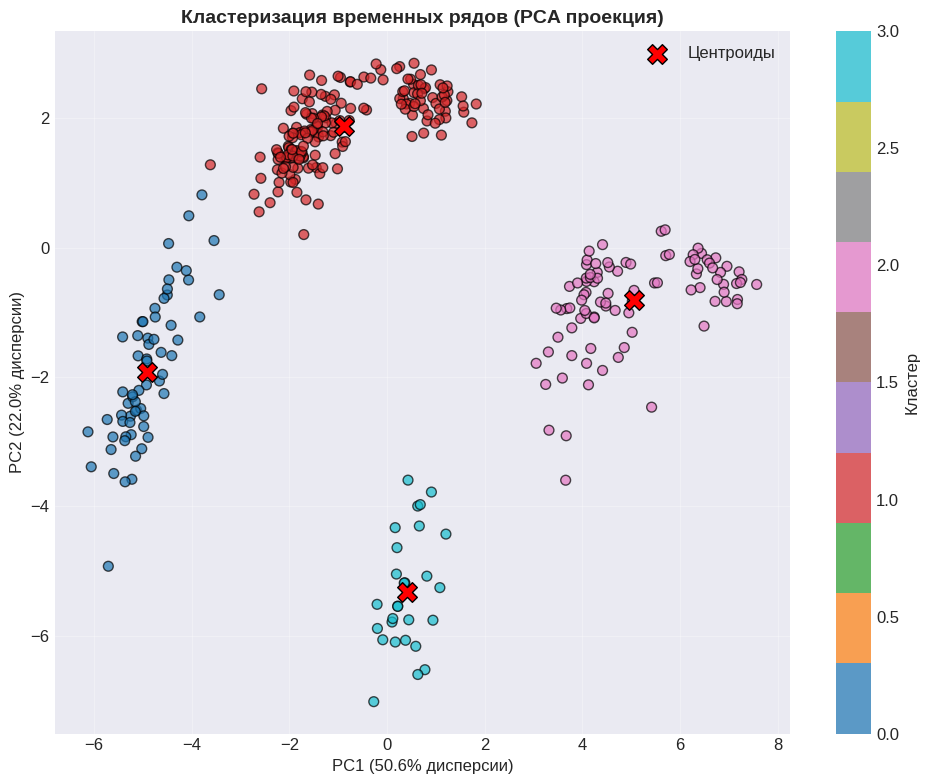


3. ПРИМЕРЫ ВРЕМЕННЫХ РЯДОВ ИЗ КАЖДОГО КЛАСТЕРА:


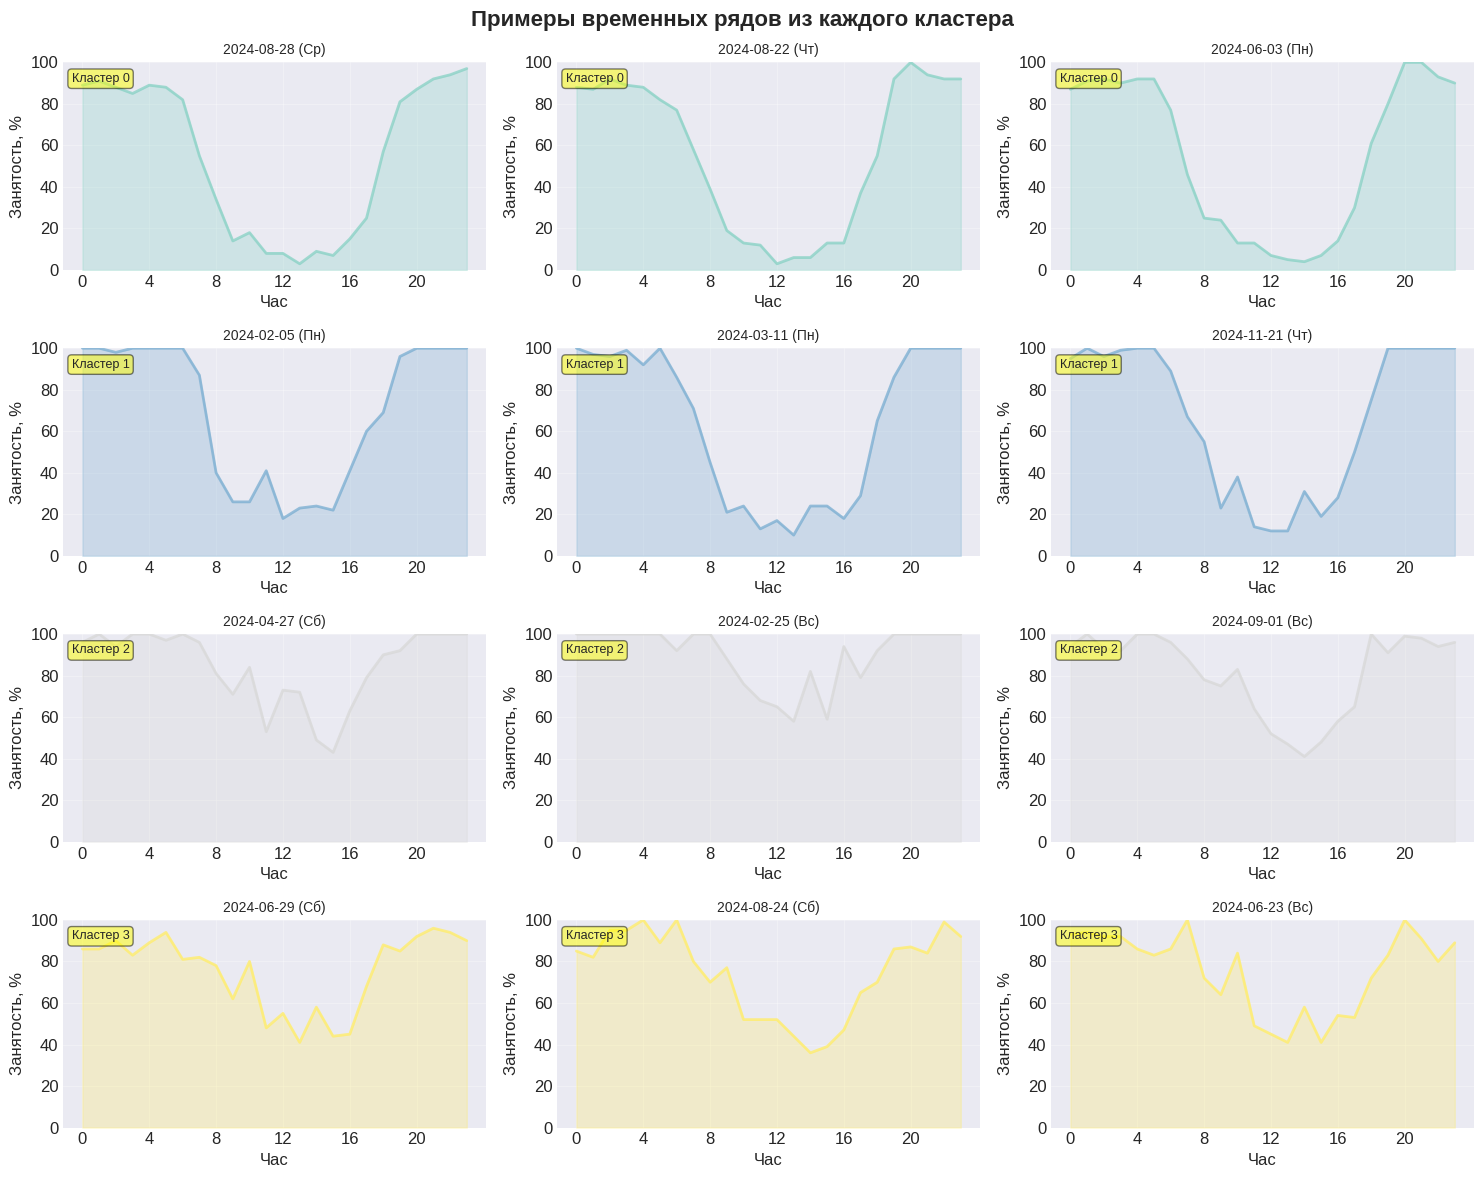


4. РАСПРЕДЕЛЕНИЕ КЛАСТЕРОВ ПО ВРЕМЕНИ:


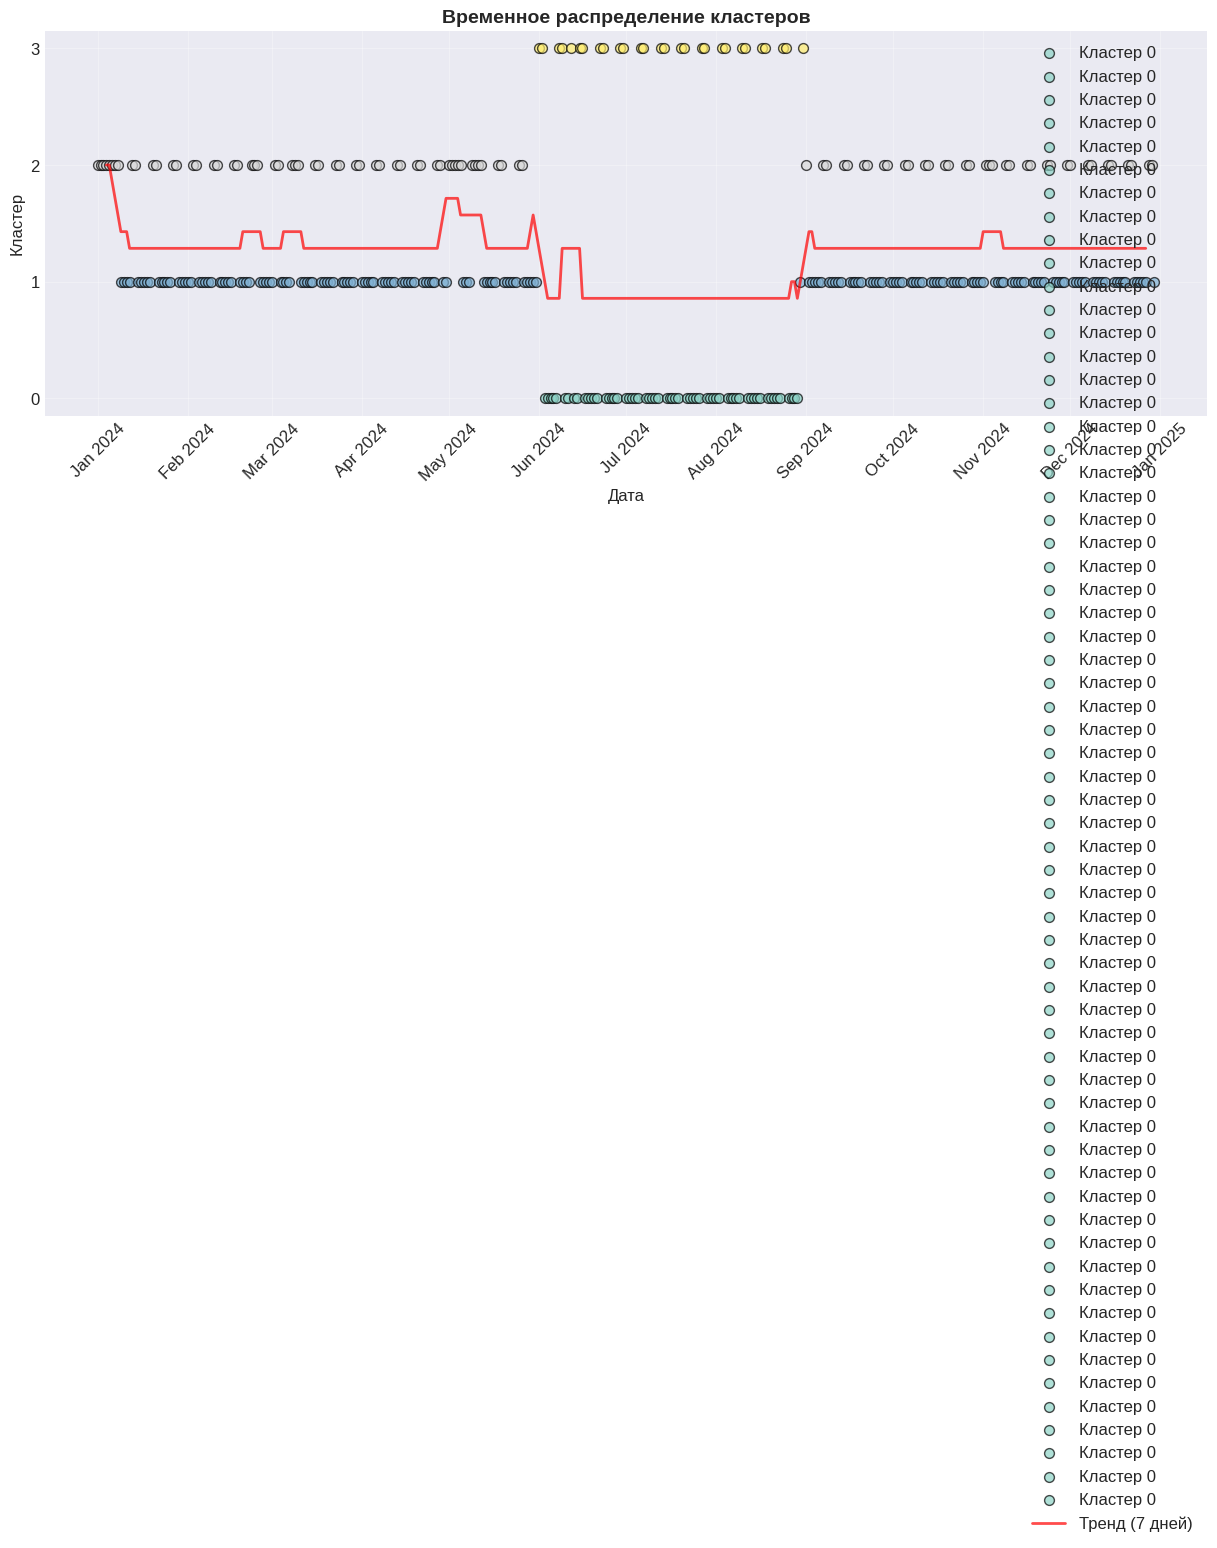


5. МАТРИЦА РАССТОЯНИЙ МЕЖДУ КЛАСТЕРАМИ:


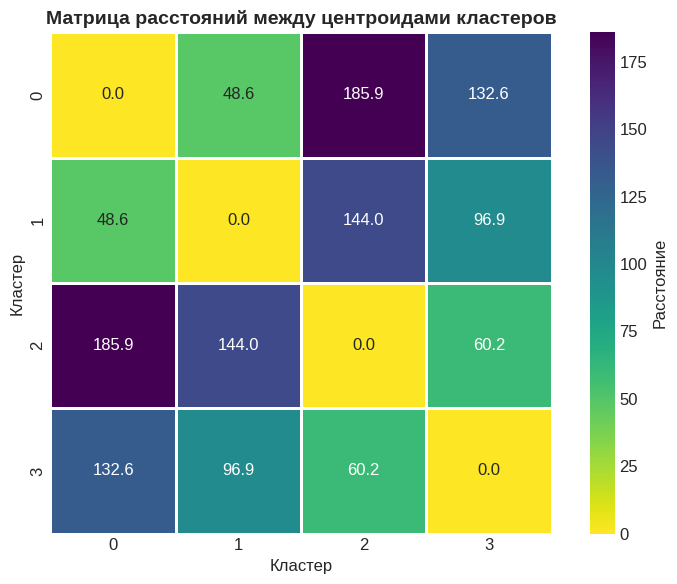


✓ Все визуализации созданы и сохранены в файлы PNG

ШАГ 4: АНАЛИЗ ХАРАКТЕРИСТИК КЛАСТЕРОВ

АНАЛИЗ ХАРАКТЕРИСТИК КЛАСТЕРОВ

СВОДНАЯ ТАБЛИЦА КЛАСТЕРОВ:
--------------------------------------------------------------------------------
Кластер Дней  Ср.занятостьПик       Мин       Типичный день  Выходных  ПраздниковПогода         
--------------------------------------------------------------------------------
0       63    56.4%       21:00 (96%)12:00 (8%)Пн (21%)       0%        0%        ясно (95%)     
1       183   65.9%       21:00 (100%)13:00 (19%)Вт (21%)       0%        0%        облачно (59%)  
2       91    86.5%       20:00 (99%)14:00 (55%)Вс (43%)       85%       22%       облачно (57%)  
3       28    75.0%       21:00 (94%)15:00 (43%)Сб (50%)       96%       4%        ясно (96%)     
--------------------------------------------------------------------------------

ТИПЫ КЛАСТЕРОВ:
  • Кластер 0: средняя загрузка, вечерний пик, преимущественно понедельники
  • Кластер 1: высок

In [30]:
# Ячейка 6: Кластеризация временных рядов занятости
print("КЛАСТЕРИЗАЦИЯ ВРЕМЕННЫХ РЯДОВ ЗАНЯТОСТИ")
print("=" * 60)

class TimeSeriesClustering:
    """Класс для кластеризации временных рядов занятости парковки"""

    def __init__(self, df):
        """
        Инициализация кластеризатора

        Parameters:
        df (pd.DataFrame): Исходные данные с почасовой детализацией
        """
        self.df = df.copy()
        self.day_profiles = None
        self.X = None
        self.X_scaled = None
        self.labels = None
        self.cluster_centers = None
        self.scaler = None
        self.kmeans = None

    def create_day_profiles_matrix(self):
        """
        Создание матрицы дневных профилей (24 значения для каждого дня)

        Returns:
        pd.DataFrame: Матрица профилей и метаданных
        """
        print("Создание матрицы дневных профилей...")

        # Проверяем наличие необходимых колонок
        required_cols = ['date', 'hour', 'occupancy_pct']
        for col in required_cols:
            if col not in self.df.columns:
                raise ValueError(f"Отсутствует обязательная колонка: {col}")

        # Преобразуем date в datetime если нужно
        if not pd.api.types.is_datetime64_any_dtype(self.df['date']):
            self.df['date'] = pd.to_datetime(self.df['date'])

        # Создаем список для хранения профилей
        profiles_data = []
        metadata_list = []

        # Группируем по датам
        self.df['date_only'] = self.df['date'].dt.date
        unique_dates = sorted(self.df['date_only'].unique())

        for date in unique_dates:
            # Фильтруем данные за день
            day_data = self.df[self.df['date_only'] == date].sort_values('hour')

            # Проверяем, что есть данные за все 24 часа (или близко к этому)
            if len(day_data) >= 20:  # Минимум 20 часов из 24
                # Создаем профиль занятости
                profile = []
                for hour in range(24):
                    hour_data = day_data[day_data['hour'] == hour]
                    if len(hour_data) > 0:
                        profile.append(hour_data['occupancy_pct'].iloc[0])
                    else:
                        # Если нет данных за час, используем интерполяцию
                        profile.append(np.nan)

                # Интерполируем пропущенные значения
                profile_series = pd.Series(profile)
                profile_interpolated = profile_series.interpolate(method='linear')
                profile_filled = profile_interpolated.ffill().bfill().values

                # Проверяем, что профиль корректный (нет NaN)
                if not np.isnan(profile_filled).any():
                    profiles_data.append(profile_filled)

                    # Собираем метаданные дня
                    metadata = {
                        'date': date,
                        'day_of_week': day_data['day_of_week'].iloc[0] if 'day_of_week' in day_data.columns else np.nan,
                        'is_weekend': day_data['is_weekend'].iloc[0] if 'is_weekend' in day_data.columns else np.nan,
                        'is_holiday': day_data['is_holiday'].iloc[0] if 'is_holiday' in day_data.columns else np.nan,
                        'avg_temperature': day_data['temperature'].mean() if 'temperature' in day_data.columns else np.nan,
                        'total_views': day_data['app_views'].sum() if 'app_views' in day_data.columns else np.nan,
                        'dominant_weather': day_data['weather'].mode()[0] if 'weather' in day_data.columns else 'неизвестно'
                    }
                    metadata_list.append(metadata)

        # Создаем DataFrame с профилями
        profiles_df = pd.DataFrame(profiles_data, columns=[f'hour_{h:02d}' for h in range(24)])

        # Создаем DataFrame с метаданными
        metadata_df = pd.DataFrame(metadata_list)

        # Объединяем
        self.day_profiles = pd.concat([metadata_df, profiles_df], axis=1)

        print(f"Создано {len(self.day_profiles)} дневных профилей")
        print(f"Размерность матрицы: {len(self.day_profiles)} дней × 24 часа")

        return self.day_profiles

    def prepare_clustering_data(self):
        """
        Подготовка данных для кластеризации
        """
        if self.day_profiles is None:
            self.create_day_profiles_matrix()

        # Извлекаем только почасовые данные
        hour_cols = [f'hour_{h:02d}' for h in range(24)]
        self.X = self.day_profiles[hour_cols].values

        # Нормализация данных (важно для кластеризации по форме, а не по величине)
        self.scaler = StandardScaler()
        self.X_scaled = self.scaler.fit_transform(self.X)

        print(f"Данные подготовлены для кластеризации")
        print(f"Форма данных: {self.X_scaled.shape}")

        return self.X_scaled

    def find_optimal_clusters(self, max_clusters=10):
        """
        Определение оптимального числа кластеров

        Parameters:
        max_clusters (int): Максимальное число кластеров для тестирования

        Returns:
        pd.DataFrame: Результаты метрик для разного числа кластеров
        """
        if self.X_scaled is None:
            self.prepare_clustering_data()

        print("\nОПРЕДЕЛЕНИЕ ОПТИМАЛЬНОГО ЧИСЛА КЛАСТЕРОВ")
        print("-" * 40)

        # Метрики для разных чисел кластеров
        inertia = []
        silhouette_scores = []
        davies_bouldin_scores = []
        cluster_range = range(2, max_clusters + 1)

        for n_clusters in cluster_range:
            print(f"Тестируем {n_clusters} кластеров...", end=' ')

            kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
            labels = kmeans.fit_predict(self.X_scaled)

            inertia.append(kmeans.inertia_)

            # Вычисляем метрики качества
            if len(set(labels)) > 1:
                silhouette_avg = silhouette_score(self.X_scaled, labels)
                silhouette_scores.append(silhouette_avg)

                davies_bouldin = davies_bouldin_score(self.X_scaled, labels)
                davies_bouldin_scores.append(davies_bouldin)

                print(f"Silhouette: {silhouette_avg:.3f}, DB: {davies_bouldin:.3f}")
            else:
                silhouette_scores.append(0)
                davies_bouldin_scores.append(np.inf)
                print("Один кластер")

        # Визуализация метрик
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        # 1. Метод локтя
        axes[0].plot(cluster_range, inertia, 'bo-', linewidth=2, markersize=8)
        axes[0].set_xlabel('Число кластеров', fontsize=12)
        axes[0].set_ylabel('Инерция', fontsize=12)
        axes[0].set_title('Метод локтя', fontsize=14, fontweight='bold')
        axes[0].grid(True, alpha=0.3)

        # 2. Силуэтный коэффициент
        axes[1].plot(cluster_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
        axes[1].set_xlabel('Число кластеров', fontsize=12)
        axes[1].set_ylabel('Силуэтный коэффициент', fontsize=12)
        axes[1].set_title('Силуэтный анализ', fontsize=14, fontweight='bold')
        axes[1].grid(True, alpha=0.3)

        # 3. Индекс Дэвиса-Боулдина
        valid_db_scores = [score for score in davies_bouldin_scores if score != np.inf]
        if valid_db_scores:
            axes[2].plot(cluster_range[:len(valid_db_scores)], valid_db_scores, 'go-',
                        linewidth=2, markersize=8)
        axes[2].set_xlabel('Число кластеров', fontsize=12)
        axes[2].set_ylabel('Индекс Дэвиса-Боулдина', fontsize=12)
        axes[2].set_title('Индекс Дэвиса-Боулдина', fontsize=14, fontweight='bold')
        axes[2].grid(True, alpha=0.3)

        plt.suptitle('Определение оптимального числа кластеров', fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.savefig('optimal_clusters.png', dpi=300, bbox_inches='tight')
        plt.show()

        # Анализ результатов
        results_df = pd.DataFrame({
            'n_clusters': list(cluster_range),
            'inertia': inertia,
            'silhouette': silhouette_scores,
            'davies_bouldin': davies_bouldin_scores
        })

        # Рекомендации
        if silhouette_scores:
            best_silhouette_idx = np.argmax(silhouette_scores)
            best_n_clusters_silhouette = cluster_range[best_silhouette_idx]
            best_silhouette_score = silhouette_scores[best_silhouette_idx]

            print(f"\nРЕКОМЕНДАЦИИ:")
            print(f"1. По силуэтному коэффициенту: {best_n_clusters_silhouette} кластеров (score: {best_silhouette_score:.3f})")

        # Находим "локоть" на графике инерции
        if len(inertia) > 2:
            # Вычисляем процентное изменение инерции
            pct_changes = []
            for i in range(1, len(inertia)):
                pct_change = (inertia[i-1] - inertia[i]) / inertia[i-1] * 100
                pct_changes.append(pct_change)

            # Находим точку, где изменение становится небольшим (менее 5%)
            elbow_point = None
            for i, change in enumerate(pct_changes):
                if i > 0 and change < 5:  # Когда изменение меньше 5%
                    elbow_point = cluster_range[i]
                    break

            if elbow_point:
                print(f"2. По методу локтя: {elbow_point} кластеров")

        return results_df

    def perform_clustering(self, n_clusters=None):
        """
        Выполнение кластеризации временных рядов

        Parameters:
        n_clusters (int): Число кластеров. Если None, определяется автоматически

        Returns:
        np.array: Метки кластеров для каждого дня
        """
        if self.X_scaled is None:
            self.prepare_clustering_data()

        # Если число кластеров не задано, определяем оптимальное
        if n_clusters is None:
            results_df = self.find_optimal_clusters()
            n_clusters = int(results_df.loc[results_df['silhouette'].idxmax(), 'n_clusters'])
            print(f"\nАвтоматически выбрано {n_clusters} кластеров")

        print(f"\nВЫПОЛНЕНИЕ КЛАСТЕРИЗАЦИИ С {n_clusters} КЛАСТЕРАМИ")
        print("-" * 40)

        # Выполняем кластеризацию K-Means
        self.kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        self.labels = self.kmeans.fit_predict(self.X_scaled)

        # Получаем центроиды
        self.cluster_centers = self.kmeans.cluster_centers_

        # Вычисляем метрики качества
        silhouette_avg = silhouette_score(self.X_scaled, self.labels)
        davies_bouldin = davies_bouldin_score(self.X_scaled, self.labels)

        print(f"Силуэтный коэффициент: {silhouette_avg:.3f}")
        print(f"Индекс Дэвиса-Боулдина: {davies_bouldin:.3f}")
        print(f"Инерция: {self.kmeans.inertia_:.2f}")

        # Добавляем метки кластеров к данным
        self.day_profiles['cluster'] = self.labels

        # Статистика по кластерам
        print("\nСТАТИСТИКА КЛАСТЕРОВ:")
        cluster_stats = self.day_profiles['cluster'].value_counts().sort_index()
        for cluster_id, count in cluster_stats.items():
            percentage = count / len(self.day_profiles) * 100
            print(f"  • Кластер {cluster_id}: {count} дней ({percentage:.1f}%)")

        return self.labels

    def visualize_clusters(self):
        """
        Визуализация результатов кластеризации
        """
        if self.labels is None:
            print("Сначала выполните кластеризацию!")
            return

        print("\nВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ КЛАСТЕРИЗАЦИИ")
        print("-" * 40)

        n_clusters = len(np.unique(self.labels))

        # 1. Центроиды кластеров (средние профили)
        print("\n1. ЦЕНТРОИДЫ КЛАСТЕРОВ:")

        # Преобразуем центроиды обратно в исходный масштаб
        centroids_original = self.scaler.inverse_transform(self.cluster_centers)

        fig, axes = plt.subplots(n_clusters, 1, figsize=(15, 3 * n_clusters))
        if n_clusters == 1:
            axes = [axes]

        colors = plt.cm.Set3(np.linspace(0, 1, n_clusters))

        for cluster_id in range(n_clusters):
            ax = axes[cluster_id]
            centroid = centroids_original[cluster_id]

            # График центроида
            ax.plot(range(24), centroid, color=colors[cluster_id],
                   linewidth=3, label=f'Центроид кластера {cluster_id}')
            ax.fill_between(range(24), centroid, alpha=0.2, color=colors[cluster_id])

            # Информация о кластере
            cluster_data = self.day_profiles[self.day_profiles['cluster'] == cluster_id]
            cluster_size = len(cluster_data)

            if cluster_size > 0:
                # Характеристики кластера
                peak_hour = np.argmax(centroid)
                peak_value = centroid[peak_hour]
                min_hour = np.argmin(centroid)
                min_value = centroid[min_hour]
                avg_occupancy = np.mean(centroid)

                info_text = f"Дней: {cluster_size} | Средняя занятость: {avg_occupancy:.1f}%"
                info_text += f"\nПик: {peak_hour}:00 ({peak_value:.1f}%) | Минимум: {min_hour}:00 ({min_value:.1f}%)"

                ax.text(0.02, 0.95, info_text, transform=ax.transAxes,
                       fontsize=9, verticalalignment='top',
                       bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

            ax.set_title(f'Кластер {cluster_id}', fontsize=12, fontweight='bold')
            ax.set_xlabel('Час', fontsize=10)
            ax.set_ylabel('Занятость, %', fontsize=10)
            ax.set_xticks(range(0, 24, 4))
            ax.set_ylim(0, 100)
            ax.grid(True, alpha=0.3)
            ax.legend(loc='upper right')

        plt.suptitle('Центроиды кластеров (средние профили занятости)',
                    fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.savefig('cluster_centroids.png', dpi=300, bbox_inches='tight')
        plt.show()

        # 2. Визуализация в 2D пространстве (PCA)
        print("\n2. ВИЗУАЛИЗАЦИЯ В 2D (PCA):")

        # Применяем PCA для снижения размерности до 2D
        pca = PCA(n_components=2)
        X_pca = pca.fit_transform(self.X_scaled)

        plt.figure(figsize=(10, 8))

        # Рассеяние точек по кластерам
        scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                             c=self.labels, cmap='tab10', s=50, alpha=0.7, edgecolors='black')

        # Центроиды в PCA пространстве
        centroids_pca = pca.transform(self.cluster_centers)
        plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
                   c='red', marker='X', s=200, label='Центроиды', edgecolors='black')

        plt.colorbar(scatter, label='Кластер')
        plt.title('Кластеризация временных рядов (PCA проекция)', fontsize=14, fontweight='bold')
        plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% дисперсии)')
        plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% дисперсии)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('clusters_pca.png', dpi=300, bbox_inches='tight')
        plt.show()

        # 3. Примеры временных рядов из каждого кластера
        print("\n3. ПРИМЕРЫ ВРЕМЕННЫХ РЯДОВ ИЗ КАЖДОГО КЛАСТЕРА:")

        examples_per_cluster = min(3, len(self.day_profiles) // n_clusters)

        fig, axes = plt.subplots(n_clusters, examples_per_cluster,
                                figsize=(5 * examples_per_cluster, 3 * n_clusters))

        if n_clusters == 1:
            axes = axes.reshape(1, -1)

        for cluster_id in range(n_clusters):
            cluster_days = self.day_profiles[self.day_profiles['cluster'] == cluster_id]

            if len(cluster_days) > 0:
                # Выбираем случайные примеры
                if len(cluster_days) > examples_per_cluster:
                    examples = cluster_days.sample(examples_per_cluster, random_state=42)
                else:
                    examples = cluster_days

                for example_idx, (_, example) in enumerate(examples.iterrows()):
                    if examples_per_cluster > 1:
                        ax = axes[cluster_id, example_idx]
                    else:
                        ax = axes[cluster_id] if n_clusters > 1 else axes[example_idx]

                    # Извлекаем данные по часам
                    hourly_data = [example[f'hour_{h:02d}'] for h in range(24)]

                    # Строим график
                    ax.plot(range(24), hourly_data, linewidth=2, alpha=0.8, color=colors[cluster_id])
                    ax.fill_between(range(24), hourly_data, alpha=0.3, color=colors[cluster_id])

                    # Информация о дне
                    date_str = str(example['date'])
                    if 'day_of_week' in example:
                        day_names = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
                        day_name = day_names[int(example['day_of_week'])] if example['day_of_week'] < 7 else 'Нд'
                        date_info = f"{date_str} ({day_name})"
                    else:
                        date_info = date_str

                    ax.set_title(date_info, fontsize=10)
                    ax.set_xlabel('Час')
                    ax.set_ylabel('Занятость, %')
                    ax.set_xticks(range(0, 24, 4))
                    ax.set_ylim(0, 100)
                    ax.grid(True, alpha=0.3)

                    # Добавляем метку кластера
                    ax.text(0.02, 0.95, f'Кластер {cluster_id}', transform=ax.transAxes,
                           fontsize=9, verticalalignment='top',
                           bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

        plt.suptitle('Примеры временных рядов из каждого кластера', fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.savefig('cluster_examples.png', dpi=300, bbox_inches='tight')
        plt.show()

        # 4. Распределение кластеров по времени
        print("\n4. РАСПРЕДЕЛЕНИЕ КЛАСТЕРОВ ПО ВРЕМЕНИ:")

        if 'date' in self.day_profiles.columns:
            # Создаем временной ряд кластеров
            timeline_df = self.day_profiles.copy()
            timeline_df['date'] = pd.to_datetime(timeline_df['date'])
            timeline_df = timeline_df.sort_values('date')

            plt.figure(figsize=(15, 5))

            # Цвета для кластеров
            colors_timeline = plt.cm.Set3(np.linspace(0, 1, n_clusters))

            # Рисуем временной ряд
            for cluster_id in range(n_clusters):
                cluster_dates = timeline_df[timeline_df['cluster'] == cluster_id]['date']

                # Создаем метки для каждого дня в кластере
                for date in cluster_dates:
                    plt.scatter(date, cluster_id, color=colors_timeline[cluster_id],
                               s=50, alpha=0.7, edgecolors='black', label=f'Кластер {cluster_id}' if cluster_id == 0 else "")

            # Добавляем сглаженную линию тренда
            timeline_df['cluster_smooth'] = timeline_df['cluster'].rolling(window=7, center=True).mean()
            plt.plot(timeline_df['date'], timeline_df['cluster_smooth'],
                    color='red', linewidth=2, alpha=0.7, label='Тренд (7 дней)')

            plt.title('Временное распределение кластеров', fontsize=14, fontweight='bold')
            plt.xlabel('Дата')
            plt.ylabel('Кластер')
            plt.yticks(range(n_clusters))
            plt.grid(True, alpha=0.3)
            plt.legend()

            # Форматируем оси дат
            plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
            plt.gca().xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator())
            plt.xticks(rotation=45)

            plt.tight_layout()
            plt.savefig('cluster_timeline.png', dpi=300, bbox_inches='tight')
            plt.show()

        # 5. Матрица расстояний между центроидами
        print("\n5. МАТРИЦА РАССТОЯНИЙ МЕЖДУ КЛАСТЕРАМИ:")

        # Вычисляем матрицу расстояний между центроидами
        distance_matrix = np.zeros((n_clusters, n_clusters))
        for i in range(n_clusters):
            for j in range(n_clusters):
                # Евклидово расстояние между центроидами
                distance_matrix[i, j] = np.linalg.norm(centroids_original[i] - centroids_original[j])

        plt.figure(figsize=(8, 6))
        sns.heatmap(distance_matrix, annot=True, fmt='.1f', cmap='viridis_r',
                   square=True, linewidths=1, cbar_kws={'label': 'Расстояние'})
        plt.title('Матрица расстояний между центроидами кластеров', fontsize=14, fontweight='bold')
        plt.xlabel('Кластер')
        plt.ylabel('Кластер')
        plt.tight_layout()
        plt.savefig('cluster_distance_matrix.png', dpi=300, bbox_inches='tight')
        plt.show()

        print("\n✓ Все визуализации созданы и сохранены в файлы PNG")

    def analyze_cluster_characteristics(self):
        """
        Анализ характеристик кластеров
        """
        if self.labels is None:
            print("Сначала выполните кластеризацию!")
            return

        print("\nАНАЛИЗ ХАРАКТЕРИСТИК КЛАСТЕРОВ")
        print("=" * 60)

        n_clusters = len(np.unique(self.labels))

        # Создаем сводную таблицу характеристик
        cluster_summary = []

        for cluster_id in range(n_clusters):
            cluster_data = self.day_profiles[self.day_profiles['cluster'] == cluster_id]

            # Основные метрики
            summary = {
                'cluster_id': cluster_id,
                'n_days': len(cluster_data),
                'percentage': len(cluster_data) / len(self.day_profiles) * 100
            }

            # Занятость
            hour_cols = [f'hour_{h:02d}' for h in range(24)]
            cluster_occupancy = cluster_data[hour_cols].values
            summary['avg_occupancy'] = np.mean(cluster_occupancy)
            summary['max_occupancy'] = np.max(cluster_occupancy)
            summary['min_occupancy'] = np.min(cluster_occupancy)

            # Пиковые часы
            centroid = self.scaler.inverse_transform([self.cluster_centers[cluster_id]])[0]
            summary['peak_hour'] = np.argmax(centroid)
            summary['peak_value'] = centroid[summary['peak_hour']]
            summary['min_hour'] = np.argmin(centroid)
            summary['min_value'] = centroid[summary['min_hour']]

            # Метаданные
            if 'day_of_week' in cluster_data.columns:
                day_dist = cluster_data['day_of_week'].value_counts()
                if len(day_dist) > 0:
                    summary['most_common_day'] = int(day_dist.idxmax())
                    summary['day_percentage'] = day_dist.max() / len(cluster_data) * 100

            if 'is_weekend' in cluster_data.columns:
                weekend_count = cluster_data['is_weekend'].sum()
                summary['weekend_percentage'] = weekend_count / len(cluster_data) * 100

            if 'is_holiday' in cluster_data.columns:
                holiday_count = cluster_data['is_holiday'].sum()
                summary['holiday_percentage'] = holiday_count / len(cluster_data) * 100

            if 'dominant_weather' in cluster_data.columns:
                weather_dist = cluster_data['dominant_weather'].value_counts()
                if len(weather_dist) > 0:
                    summary['most_common_weather'] = weather_dist.idxmax()
                    summary['weather_percentage'] = weather_dist.max() / len(cluster_data) * 100

            cluster_summary.append(summary)

        # Создаем DataFrame с результатами
        summary_df = pd.DataFrame(cluster_summary)

        # Выводим результаты
        print("\nСВОДНАЯ ТАБЛИЦА КЛАСТЕРОВ:")
        print("-" * 80)

        # Определяем ширину колонок для красивого вывода
        col_widths = {
            'Кластер': 8,
            'Дней': 6,
            'Ср.занятость': 12,
            'Пик': 10,
            'Мин': 10,
            'Типичный день': 15,
            'Выходных': 10,
            'Праздников': 10,
            'Погода': 15
        }

        # Заголовок
        header = ""
        for col, width in col_widths.items():
            header += f"{col:<{width}}"
        print(header)
        print("-" * 80)

        # Данные
        day_names = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']

        for idx, row in summary_df.iterrows():
            # Формируем строку
            cluster_str = f"{int(row['cluster_id'])}"
            days_str = f"{int(row['n_days'])}"
            avg_occ_str = f"{row['avg_occupancy']:.1f}%"
            peak_str = f"{int(row['peak_hour'])}:00 ({row['peak_value']:.0f}%)"
            min_str = f"{int(row['min_hour'])}:00 ({row['min_value']:.0f}%)"

            # Типичный день
            if 'most_common_day' in row:
                day_name = day_names[int(row['most_common_day'])] if row['most_common_day'] < 7 else 'Нд'
                day_str = f"{day_name} ({row.get('day_percentage', 0):.0f}%)"
            else:
                day_str = "н/д"

            # Выходные
            weekend_str = f"{row.get('weekend_percentage', 0):.0f}%"

            # Праздники
            holiday_str = f"{row.get('holiday_percentage', 0):.0f}%"

            # Погода
            if 'most_common_weather' in row:
                weather_str = f"{row['most_common_weather']} ({row.get('weather_percentage', 0):.0f}%)"
            else:
                weather_str = "н/д"

            # Выводим строку
            data_row = f"{cluster_str:<8}{days_str:<6}{avg_occ_str:<12}{peak_str:<10}{min_str:<10}"
            data_row += f"{day_str:<15}{weekend_str:<10}{holiday_str:<10}{weather_str:<15}"
            print(data_row)

        print("-" * 80)

        # Определяем типы кластеров
        print("\nТИПЫ КЛАСТЕРОВ:")
        for idx, row in summary_df.iterrows():
            cluster_type = self._determine_cluster_type(row)
            print(f"  • Кластер {int(row['cluster_id'])}: {cluster_type}")

        return summary_df

    def _determine_cluster_type(self, cluster_info):
        """Определение типа кластера на основе характеристик"""
        avg_occupancy = cluster_info['avg_occupancy']
        peak_hour = cluster_info['peak_hour']
        peak_value = cluster_info['peak_value']

        # Определяем уровень загрузки
        if avg_occupancy > 80:
            load_level = "очень высокая загрузка"
        elif avg_occupancy > 60:
            load_level = "высокая загрузка"
        elif avg_occupancy > 40:
            load_level = "средняя загрузка"
        else:
            load_level = "низкая загрузка"

        # Определяем профиль по пиковым часам
        if peak_hour < 12:
            peak_profile = "утренний пик"
        elif peak_hour < 18:
            peak_profile = "дневной пик"
        else:
            peak_profile = "вечерний пик"

        # Определяем тип дня
        day_type = ""
        if 'weekend_percentage' in cluster_info and cluster_info['weekend_percentage'] > 70:
            day_type = "выходные дни"
        elif 'holiday_percentage' in cluster_info and cluster_info['holiday_percentage'] > 50:
            day_type = "праздничные дни"
        elif 'most_common_day' in cluster_info:
            day_names = ['понедельники', 'вторники', 'среды', 'четверги',
                        'пятницы', 'субботы', 'воскресенья']
            day_idx = int(cluster_info['most_common_day'])
            if day_idx < 7:
                day_type = day_names[day_idx]

        # Формируем описание
        description = f"{load_level}, {peak_profile}"
        if day_type:
            description += f", преимущественно {day_type}"

        return description

    def save_results(self, filename='clustering_results.xlsx'):
        """
        Сохранение результатов кластеризации

        Parameters:
        filename (str): Имя файла для сохранения
        """
        if self.day_profiles is None:
            print("Нет данных для сохранения!")
            return

        # Создаем Excel writer
        with pd.ExcelWriter(filename, engine='openpyxl') as writer:
            # Сохраняем кластеризованные данные
            self.day_profiles.to_excel(writer, sheet_name='Clustered_Days', index=False)

            # Сохраняем центроиды
            centroids_original = self.scaler.inverse_transform(self.cluster_centers)
            centroids_df = pd.DataFrame(centroids_original,
                                       columns=[f'hour_{h:02d}' for h in range(24)])
            centroids_df['cluster'] = range(len(centroids_df))
            centroids_df.to_excel(writer, sheet_name='Cluster_Centroids', index=False)

            # Сохраняем сводную статистику
            summary_df = self.analyze_cluster_characteristics()
            summary_df.to_excel(writer, sheet_name='Cluster_Summary', index=False)

            # Сохраняем метрики кластеризации
            metrics_df = pd.DataFrame({
                'metric': ['n_clusters', 'silhouette_score', 'davies_bouldin_score', 'inertia'],
                'value': [len(np.unique(self.labels)),
                         silhouette_score(self.X_scaled, self.labels),
                         davies_bouldin_score(self.X_scaled, self.labels),
                         self.kmeans.inertia_]
            })
            metrics_df.to_excel(writer, sheet_name='Clustering_Metrics', index=False)

        print(f"✓ Результаты сохранены в файл: {filename}")

# Создаем и запускаем кластеризатор
print("Инициализация кластеризатора временных рядов...")
cluster_analyzer = TimeSeriesClustering(df)

# 1. Создаем матрицу дневных профилей
daily_profiles = cluster_analyzer.create_day_profiles_matrix()

# 2. Определяем оптимальное число кластеров
print("\n" + "=" * 60)
print("ШАГ 1: ОПРЕДЕЛЕНИЕ ОПТИМАЛЬНОГО ЧИСЛА КЛАСТЕРОВ")
print("=" * 60)

results_df = cluster_analyzer.find_optimal_clusters(max_clusters=10)

# 3. Выполняем кластеризацию
print("\n" + "=" * 60)
print("ШАГ 2: ВЫПОЛНЕНИЕ КЛАСТЕРИЗАЦИИ")
print("=" * 60)

# Можно задать число кластеров вручную или оставить None для автоматического выбора
# n_clusters_input = input("Введите число кластеров (Enter для автоматического выбора): ").strip()
# if n_clusters_input:
n_clusters = 4
# else:
    # n_clusters = None

labels = cluster_analyzer.perform_clustering(n_clusters=n_clusters)

# 4. Визуализируем результаты
print("\n" + "=" * 60)
print("ШАГ 3: ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ")
print("=" * 60)

cluster_analyzer.visualize_clusters()

# 5. Анализируем характеристики кластеров
print("\n" + "=" * 60)
print("ШАГ 4: АНАЛИЗ ХАРАКТЕРИСТИК КЛАСТЕРОВ")
print("=" * 60)

summary_df = cluster_analyzer.analyze_cluster_characteristics()

# 6. Сохраняем результаты
print("\n" + "=" * 60)
print("ШАГ 5: СОХРАНЕНИЕ РЕЗУЛЬТАТОВ")
print("=" * 60)

cluster_analyzer.save_results('time_series_clustering_results.xlsx')

print("\n" + "=" * 60)
print("КЛАСТЕРИЗАЦИЯ ВРЕМЕННЫХ РЯДОВ УСПЕШНО ЗАВЕРШЕНА!")
print("=" * 60)
print("\nСозданы файлы:")
print("  1. optimal_clusters.png - графики для выбора числа кластеров")
print("  2. cluster_centroids.png - центроиды кластеров")
print("  3. clusters_pca.png - визуализация кластеров в 2D")
print("  4. cluster_examples.png - примеры временных рядов из кластеров")
print("  5. cluster_timeline.png - временное распределение кластеров")
print("  6. cluster_distance_matrix.png - матрица расстояний между кластерами")
print("  7. time_series_clustering_results.xlsx - детальные результаты кластеризации")

## 3. Анализ кластеров

In [33]:
# Загружаем сохраненные результаты
cluster_results = pd.read_excel('time_series_clustering_results.xlsx', sheet_name=None)
clustered_days = cluster_results['Clustered_Days']
cluster_summary = cluster_results['Cluster_Summary']

print("Количество дней в каждом кластере:")
cluster_counts = clustered_days['cluster'].value_counts().sort_index()
for cluster_id, count in cluster_counts.items():
    print(f"  • Кластер {cluster_id}: {count} дней ({count/len(clustered_days)*100:.1f}%)")

Количество дней в каждом кластере:
  • Кластер 0: 63 дней (17.3%)
  • Кластер 1: 183 дней (50.1%)
  • Кластер 2: 91 дней (24.9%)
  • Кластер 3: 28 дней (7.7%)



РАЗЛИЧИЯ В ПРОФИЛЯХ ЗАНЯТОСТИ МЕЖДУ КЛАСТЕРАМИ


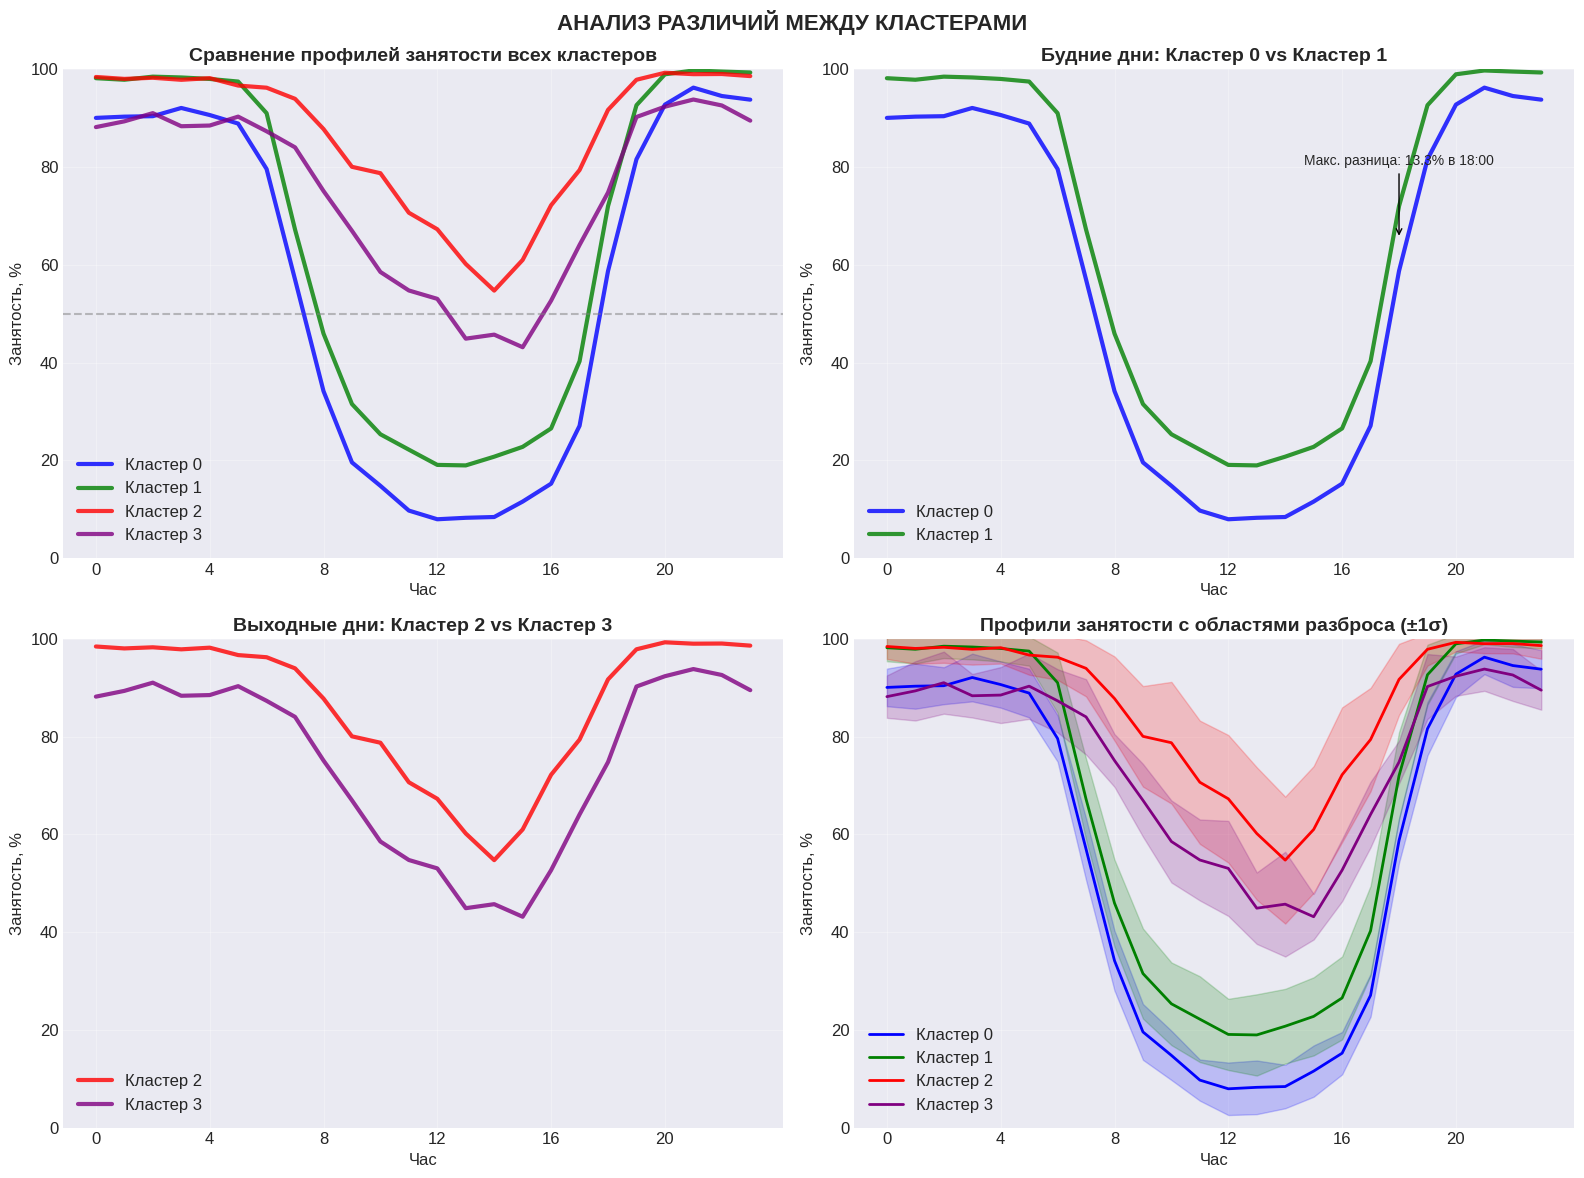

In [34]:
# Ячейка 8: Визуализация различий в профилях занятости между кластерами
print("\nРАЗЛИЧИЯ В ПРОФИЛЯХ ЗАНЯТОСТИ МЕЖДУ КЛАСТЕРАМИ")
print("=" * 60)

# Загружаем центроиды кластеров
centroids_df = cluster_results['Cluster_Centroids']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Цвета для кластеров
colors = ['blue', 'green', 'red', 'purple']
cluster_names = ['Кластер 0', 'Кластер 1', 'Кластер 2', 'Кластер 3']

# 1. Все центроиды на одном графике для сравнения
ax = axes[0, 0]
for cluster_id in range(4):
    centroid = centroids_df[centroids_df['cluster'] == cluster_id]
    if len(centroid) > 0:
        # Извлекаем почасовые данные (колонки hour_00..hour_23)
        hour_cols = [f'hour_{h:02d}' for h in range(24)]
        profile = centroid[hour_cols].values[0]
        ax.plot(range(24), profile, label=cluster_names[cluster_id],
                color=colors[cluster_id], linewidth=3, alpha=0.8)

ax.set_title('Сравнение профилей занятости всех кластеров', fontsize=14, fontweight='bold')
ax.set_xlabel('Час', fontsize=12)
ax.set_ylabel('Занятость, %', fontsize=12)
ax.set_xticks(range(0, 24, 4))
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)
ax.legend()
ax.axhline(y=50, color='gray', linestyle='--', alpha=0.5)

# 2. Разница между кластером 0 и 1 (будни)
ax = axes[0, 1]
for cluster_id in [0, 1]:
    centroid = centroids_df[centroids_df['cluster'] == cluster_id]
    if len(centroid) > 0:
        hour_cols = [f'hour_{h:02d}' for h in range(24)]
        profile = centroid[hour_cols].values[0]
        ax.plot(range(24), profile, label=cluster_names[cluster_id],
                color=colors[cluster_id], linewidth=3, alpha=0.8)

ax.set_title('Будние дни: Кластер 0 vs Кластер 1', fontsize=14, fontweight='bold')
ax.set_xlabel('Час', fontsize=12)
ax.set_ylabel('Занятость, %', fontsize=12)
ax.set_xticks(range(0, 24, 4))
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)
ax.legend()

# Вычисляем разницу
centroid_0 = centroids_df[centroids_df['cluster'] == 0]
centroid_1 = centroids_df[centroids_df['cluster'] == 1]
if len(centroid_0) > 0 and len(centroid_1) > 0:
    profile_0 = centroid_0[[f'hour_{h:02d}' for h in range(24)]].values[0]
    profile_1 = centroid_1[[f'hour_{h:02d}' for h in range(24)]].values[0]
    difference = profile_1 - profile_0

    # Аннотируем максимальную разницу
    max_diff_hour = np.argmax(np.abs(difference))
    max_diff_value = difference[max_diff_hour]
    ax.annotate(f'Макс. разница: {max_diff_value:.1f}% в {max_diff_hour}:00',
                xy=(max_diff_hour, (profile_0[max_diff_hour] + profile_1[max_diff_hour])/2),
                xytext=(max_diff_hour, (profile_0[max_diff_hour] + profile_1[max_diff_hour])/2 + 15),
                arrowprops=dict(arrowstyle='->', color='black'),
                fontsize=10, ha='center')

# 3. Разница между кластером 2 и 3 (выходные)
ax = axes[1, 0]
for cluster_id in [2, 3]:
    centroid = centroids_df[centroids_df['cluster'] == cluster_id]
    if len(centroid) > 0:
        hour_cols = [f'hour_{h:02d}' for h in range(24)]
        profile = centroid[hour_cols].values[0]
        ax.plot(range(24), profile, label=cluster_names[cluster_id],
                color=colors[cluster_id], linewidth=3, alpha=0.8)

ax.set_title('Выходные дни: Кластер 2 vs Кластер 3', fontsize=14, fontweight='bold')
ax.set_xlabel('Час', fontsize=12)
ax.set_ylabel('Занятость, %', fontsize=12)
ax.set_xticks(range(0, 24, 4))
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)
ax.legend()

# 4. График различий между кластерами
ax = axes[1, 1]
# Вычисляем среднюю занятость по часам для каждого кластера
cluster_means = []
for cluster_id in range(4):
    cluster_data = clustered_days[clustered_days['cluster'] == cluster_id]
    hour_cols = [f'hour_{h:02d}' for h in range(24)]
    hourly_means = cluster_data[hour_cols].mean()
    cluster_means.append(hourly_means.values)

cluster_means = np.array(cluster_means)

# Вычисляем вариативность (разброс) внутри кластеров
cluster_std = []
for cluster_id in range(4):
    cluster_data = clustered_days[clustered_days['cluster'] == cluster_id]
    hour_cols = [f'hour_{h:02d}' for h in range(24)]
    hourly_std = cluster_data[hour_cols].std()
    cluster_std.append(hourly_std.values)

cluster_std = np.array(cluster_std)

# График с областями разброса
for cluster_id in range(4):
    ax.fill_between(range(24),
                    cluster_means[cluster_id] - cluster_std[cluster_id],
                    cluster_means[cluster_id] + cluster_std[cluster_id],
                    alpha=0.2, color=colors[cluster_id])
    ax.plot(range(24), cluster_means[cluster_id], label=cluster_names[cluster_id],
            color=colors[cluster_id], linewidth=2)

ax.set_title('Профили занятости с областями разброса (±1σ)', fontsize=14, fontweight='bold')
ax.set_xlabel('Час', fontsize=12)
ax.set_ylabel('Занятость, %', fontsize=12)
ax.set_xticks(range(0, 24, 4))
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)
ax.legend()

plt.suptitle('АНАЛИЗ РАЗЛИЧИЙ МЕЖДУ КЛАСТЕРАМИ', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('cluster_differences.png', dpi=300, bbox_inches='tight')
plt.show()


АНАЛИЗ МЕТАДАННЫХ КЛАСТЕРОВ


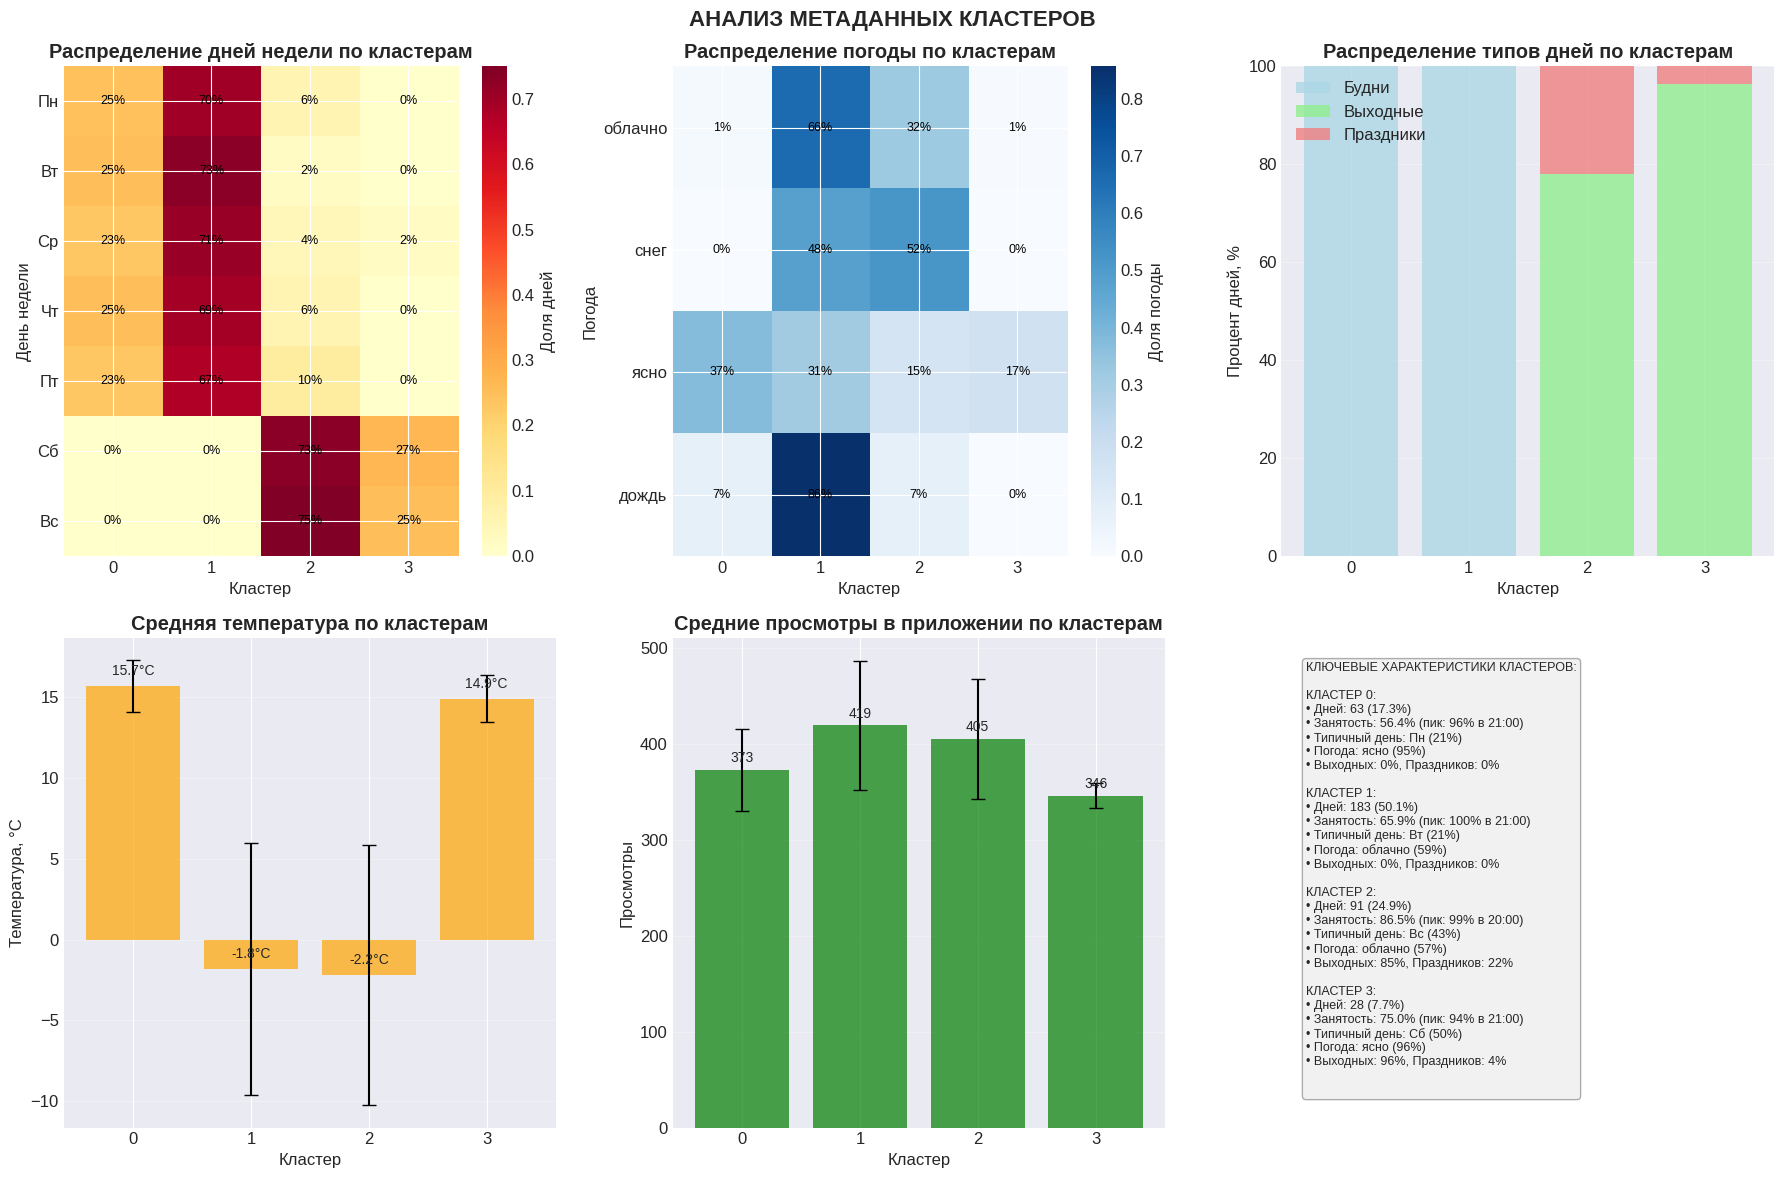

In [35]:
# Ячейка 9: Анализ метаданных - что отличает кластеры?
print("\nАНАЛИЗ МЕТАДАННЫХ КЛАСТЕРОВ")
print("=" * 60)

# Создаем расширенный анализ метаданных
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Распределение дней недели по кластерам
ax = axes[0, 0]
day_names = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']

# Создаем матрицу для heatmap
day_cluster_matrix = np.zeros((7, 4))

for cluster_id in range(4):
    cluster_data = clustered_days[clustered_days['cluster'] == cluster_id]
    for day in range(7):
        day_count = len(cluster_data[cluster_data['day_of_week'] == day])
        day_cluster_matrix[day, cluster_id] = day_count

# Нормализуем по строкам (дням недели)
day_cluster_matrix_norm = day_cluster_matrix / day_cluster_matrix.sum(axis=1, keepdims=True)

im = ax.imshow(day_cluster_matrix_norm, cmap='YlOrRd', aspect='auto')
ax.set_title('Распределение дней недели по кластерам', fontweight='bold')
ax.set_xlabel('Кластер')
ax.set_ylabel('День недели')
ax.set_xticks(range(4))
ax.set_yticks(range(7))
ax.set_xticklabels(['0', '1', '2', '3'])
ax.set_yticklabels(day_names)

# Добавляем значения в ячейки
for i in range(7):
    for j in range(4):
        text = ax.text(j, i, f'{day_cluster_matrix_norm[i, j]*100:.0f}%',
                      ha="center", va="center", color="black", fontsize=9)

plt.colorbar(im, ax=ax, label='Доля дней')

# 2. Распределение погоды по кластерам
ax = axes[0, 1]
weather_types = clustered_days['dominant_weather'].unique()

# Создаем матрицу для heatmap
weather_cluster_matrix = np.zeros((len(weather_types), 4))

for i, weather in enumerate(weather_types):
    for cluster_id in range(4):
        cluster_data = clustered_days[clustered_days['cluster'] == cluster_id]
        weather_count = len(cluster_data[cluster_data['dominant_weather'] == weather])
        weather_cluster_matrix[i, cluster_id] = weather_count

# Нормализуем по строкам
weather_cluster_matrix_norm = weather_cluster_matrix / weather_cluster_matrix.sum(axis=1, keepdims=True)

im = ax.imshow(weather_cluster_matrix_norm, cmap='Blues', aspect='auto')
ax.set_title('Распределение погоды по кластерам', fontweight='bold')
ax.set_xlabel('Кластер')
ax.set_ylabel('Погода')
ax.set_xticks(range(4))
ax.set_yticks(range(len(weather_types)))
ax.set_xticklabels(['0', '1', '2', '3'])
ax.set_yticklabels(weather_types)

# Добавляем значения
for i in range(len(weather_types)):
    for j in range(4):
        if not np.isnan(weather_cluster_matrix_norm[i, j]):
            text = ax.text(j, i, f'{weather_cluster_matrix_norm[i, j]*100:.0f}%',
                          ha="center", va="center", color="black", fontsize=9)

plt.colorbar(im, ax=ax, label='Доля погоды')

# 3. Распределение праздников/выходных
ax = axes[0, 2]
cluster_types = ['Будни', 'Выходные', 'Праздники']

# Считаем для каждого кластера
cluster_stats = []
for cluster_id in range(4):
    cluster_data = clustered_days[clustered_days['cluster'] == cluster_id]

    # Будни (не выходные и не праздники)
    workdays = len(cluster_data[(cluster_data['is_weekend'] == 0) & (cluster_data['is_holiday'] == 0)])
    # Выходные (но не праздники)
    weekends = len(cluster_data[(cluster_data['is_weekend'] == 1) & (cluster_data['is_holiday'] == 0)])
    # Праздники
    holidays = len(cluster_data[cluster_data['is_holiday'] == 1])

    total = workdays + weekends + holidays
    if total > 0:
        cluster_stats.append([workdays/total*100, weekends/total*100, holidays/total*100])
    else:
        cluster_stats.append([0, 0, 0])

cluster_stats = np.array(cluster_stats)

# Строим stacked bar chart
x = range(4)
bottom = np.zeros(4)
colors_type = ['lightblue', 'lightgreen', 'lightcoral']

for i, (type_name, color) in enumerate(zip(cluster_types, colors_type)):
    ax.bar(x, cluster_stats[:, i], bottom=bottom, label=type_name, color=color, alpha=0.8)
    bottom += cluster_stats[:, i]

ax.set_title('Распределение типов дней по кластерам', fontweight='bold')
ax.set_xlabel('Кластер')
ax.set_ylabel('Процент дней, %')
ax.set_xticks(x)
ax.set_xticklabels(['0', '1', '2', '3'])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# 4. Средняя температура по кластерам
ax = axes[1, 0]
temp_by_cluster = []
temp_std_by_cluster = []

for cluster_id in range(4):
    cluster_data = clustered_days[clustered_days['cluster'] == cluster_id]
    temp_data = cluster_data['avg_temperature'].dropna()
    if len(temp_data) > 0:
        temp_by_cluster.append(temp_data.mean())
        temp_std_by_cluster.append(temp_data.std())
    else:
        temp_by_cluster.append(0)
        temp_std_by_cluster.append(0)

bars = ax.bar(range(4), temp_by_cluster, yerr=temp_std_by_cluster,
             capsize=5, alpha=0.7, color='orange')
ax.set_title('Средняя температура по кластерам', fontweight='bold')
ax.set_xlabel('Кластер')
ax.set_ylabel('Температура, °C')
ax.set_xticks(range(4))
ax.set_xticklabels(['0', '1', '2', '3'])
ax.grid(True, alpha=0.3, axis='y')

# Добавляем значения на столбцы
for i, (bar, temp) in enumerate(zip(bars, temp_by_cluster)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{temp:.1f}°C', ha='center', va='bottom', fontsize=10)

# 5. Просмотры в приложении по кластерам
ax = axes[1, 1]
views_by_cluster = []
views_std_by_cluster = []

for cluster_id in range(4):
    cluster_data = clustered_days[clustered_days['cluster'] == cluster_id]
    views_data = cluster_data['total_views'].dropna()
    if len(views_data) > 0:
        views_by_cluster.append(views_data.mean())
        views_std_by_cluster.append(views_data.std())
    else:
        views_by_cluster.append(0)
        views_std_by_cluster.append(0)

bars = ax.bar(range(4), views_by_cluster, yerr=views_std_by_cluster,
             capsize=5, alpha=0.7, color='green')
ax.set_title('Средние просмотры в приложении по кластерам', fontweight='bold')
ax.set_xlabel('Кластер')
ax.set_ylabel('Просмотры')
ax.set_xticks(range(4))
ax.set_xticklabels(['0', '1', '2', '3'])
ax.grid(True, alpha=0.3, axis='y')

# Добавляем значения на столбцы
for i, (bar, views) in enumerate(zip(bars, views_by_cluster)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 5,
            f'{views:.0f}', ha='center', va='bottom', fontsize=10)

# 6. Ключевые статистики по кластерам
ax = axes[1, 2]
ax.axis('off')

# Создаем текстовую сводку
summary_text = "КЛЮЧЕВЫЕ ХАРАКТЕРИСТИКИ КЛАСТЕРОВ:\n\n"

for cluster_id in range(4):
    cluster_data = clustered_days[clustered_days['cluster'] == cluster_id]

    # Основные статистики
    hour_cols = [f'hour_{h:02d}' for h in range(24)]
    occupancy_data = cluster_data[hour_cols].values
    avg_occupancy = np.mean(occupancy_data)
    max_occupancy = np.max(occupancy_data)
    min_occupancy = np.min(occupancy_data)

    # Пиковые часы
    centroid = centroids_df[centroids_df['cluster'] == cluster_id]
    if len(centroid) > 0:
        profile = centroid[hour_cols].values[0]
        peak_hour = np.argmax(profile)
        peak_value = profile[peak_hour]
        min_hour = np.argmin(profile)
        min_value = profile[min_hour]

    # День недели
    day_dist = cluster_data['day_of_week'].value_counts()
    if len(day_dist) > 0:
        common_day = int(day_dist.idxmax())
        day_name = day_names[common_day] if common_day < 7 else 'Нд'
        day_percentage = day_dist.max() / len(cluster_data) * 100
    else:
        day_name = 'разные'
        day_percentage = 0

    # Погода
    weather_dist = cluster_data['dominant_weather'].value_counts()
    if len(weather_dist) > 0:
        common_weather = weather_dist.idxmax()
        weather_percentage = weather_dist.max() / len(cluster_data) * 100
    else:
        common_weather = 'разная'
        weather_percentage = 0

    # Тип дня
    weekend_percentage = cluster_data['is_weekend'].mean() * 100
    holiday_percentage = cluster_data['is_holiday'].mean() * 100

    summary_text += f"КЛАСТЕР {cluster_id}:\n"
    summary_text += f"• Дней: {len(cluster_data)} ({len(cluster_data)/len(clustered_days)*100:.1f}%)\n"
    summary_text += f"• Занятость: {avg_occupancy:.1f}% (пик: {peak_value:.0f}% в {peak_hour}:00)\n"
    summary_text += f"• Типичный день: {day_name} ({day_percentage:.0f}%)\n"
    summary_text += f"• Погода: {common_weather} ({weather_percentage:.0f}%)\n"
    summary_text += f"• Выходных: {weekend_percentage:.0f}%, Праздников: {holiday_percentage:.0f}%\n\n"

ax.text(0.05, 0.95, summary_text, transform=ax.transAxes,
       fontsize=9, verticalalignment='top',
       bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.3))

plt.suptitle('АНАЛИЗ МЕТАДАННЫХ КЛАСТЕРОВ', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('cluster_metadata_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Определение значимости фич для кластеризации

АНАЛИЗ ЗНАЧИМОСТИ ПРИЗНАКОВ ДЛЯ КЛАСТЕРИЗАЦИИ
Анализируем 6 признаков...


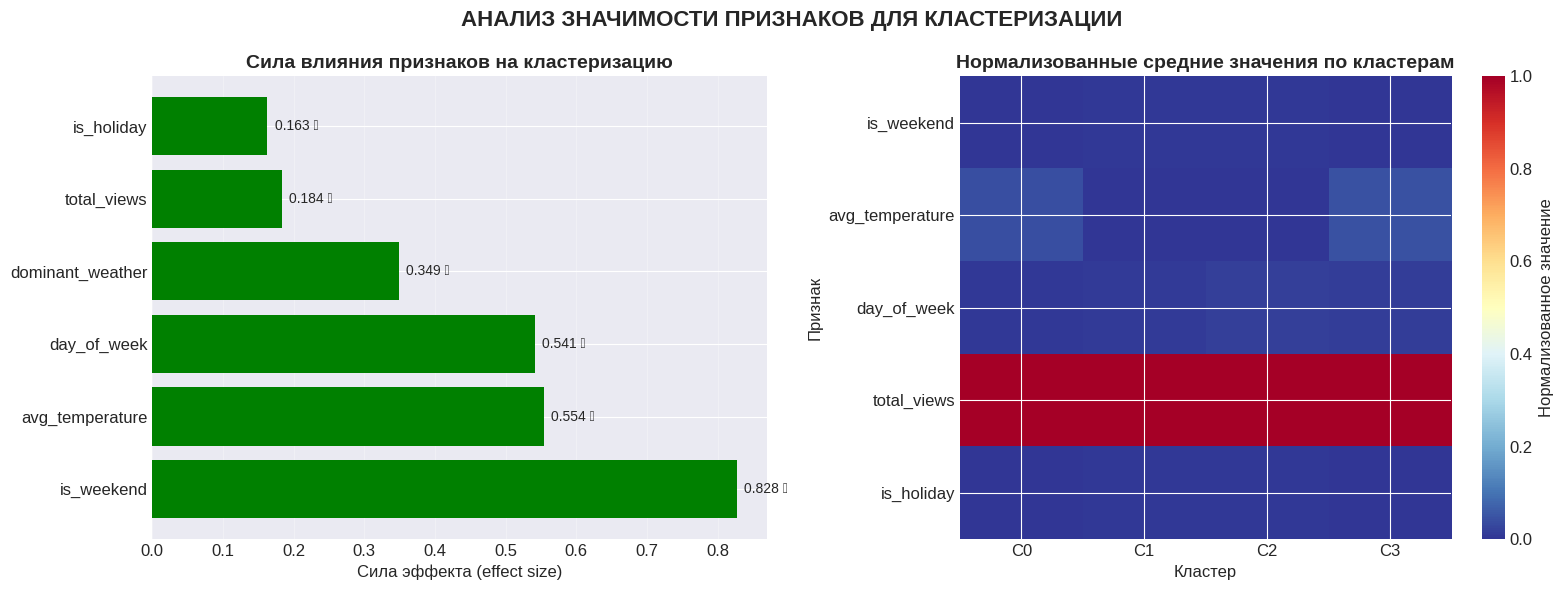


РЕКОМЕНДАЦИИ ПО ПРИЗНАКАМ:
--------------------------------------------------
✓ is_weekend: сильный эффект (effect size: 0.828, p=0.0000)
✓ avg_temperature: сильный эффект (effect size: 0.554, p=0.0000)
✓ day_of_week: сильный эффект (effect size: 0.541, p=0.0000)
✓ dominant_weather: сильный эффект (effect size: 0.349, p=0.0000)
✓ total_views: сильный эффект (effect size: 0.184, p=0.0000)
✓ is_holiday: сильный эффект (effect size: 0.163, p=0.0000)

ПРИЗНАКИ, КОТОРЫЕ МОЖНО УБРАТЬ (незначимые):

✓ Результаты анализа сохранены в 'feature_importance_analysis.xlsx'


In [44]:
# Ячейка 13: Анализ значимости фич для кластеризации (ИСПРАВЛЕННАЯ)
print("АНАЛИЗ ЗНАЧИМОСТИ ПРИЗНАКОВ ДЛЯ КЛАСТЕРИЗАЦИИ")
print("=" * 60)

def analyze_feature_importance_for_clusters(clustered_data, features_to_test):
    """
    Анализирует, насколько сильно признаки влияют на разделение кластеров

    Parameters:
    clustered_data (pd.DataFrame): Данные с метками кластеров
    features_to_test (list): Список признаков для анализа

    Returns:
    pd.DataFrame: DataFrame с оценкой важности признаков
    """

    from scipy import stats
    import warnings
    warnings.filterwarnings('ignore')

    results = []
    n_clusters = len(clustered_data['cluster'].unique())

    for feature in features_to_test:
        if feature in clustered_data.columns:
            # Пропускаем строковые признаки или те, что не подходят для статистических тестов
            if clustered_data[feature].dtype == 'object' or feature == 'dominant_weather':
                # Для категориальных признаков используем хи-квадрат тест
                try:
                    # Создаем таблицу сопряженности
                    contingency_table = pd.crosstab(clustered_data[feature], clustered_data['cluster'])

                    if contingency_table.size > 0:
                        chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

                        # Вычисляем силу эффекта (Cramer's V)
                        n = contingency_table.sum().sum()
                        phi2 = chi2 / n
                        r, k = contingency_table.shape
                        phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
                        rcorr = r - ((r-1)**2)/(n-1)
                        kcorr = k - ((k-1)**2)/(n-1)
                        effect_size = np.sqrt(phi2corr / min((kcorr-1), (rcorr-1))) if min((kcorr-1), (rcorr-1)) > 0 else 0

                        effect_strength = "сильный" if effect_size > 0.3 else "средний" if effect_size > 0.1 else "слабый" if effect_size > 0.05 else "очень слабый"

                        results.append({
                            'feature': feature,
                            'test': 'Хи-квадрат',
                            'p_value': p_value,
                            'significant': p_value < 0.05,
                            'effect_size': effect_size,
                            'effect_strength': effect_strength,
                            'range_ratio': np.nan,
                            'data_type': 'категориальный'
                        })
                except Exception as e:
                    print(f"Ошибка при анализе {feature}: {e}")
                    continue

            else:
                # Для числовых признаков
                try:
                    cluster_groups = []
                    for cluster_id in range(n_clusters):
                        cluster_data = clustered_data[clustered_data['cluster'] == cluster_id][feature].dropna()
                        if len(cluster_data) > 0:
                            cluster_groups.append(cluster_data)

                    if len(cluster_groups) >= 2 and all([len(g) > 1 for g in cluster_groups]):
                        # Проверяем нормальность распределения
                        normality_results = []
                        for group in cluster_groups:
                            if len(group) > 3:
                                _, p_value_norm = stats.shapiro(group)
                                normality_results.append(p_value_norm > 0.05)
                            else:
                                normality_results.append(True)

                        all_normal = all(normality_results)

                        # Выбираем статистический тест
                        if all_normal:
                            # ANOVA для нормальных распределений
                            f_stat, p_value = stats.f_oneway(*cluster_groups)
                            test_name = "ANOVA"

                            # Eta-squared для ANOVA
                            ss_between = f_stat * (len(clustered_data) - n_clusters)
                            ss_total = ss_between + (len(clustered_data) - n_clusters) * (1 + f_stat)
                            effect_size = ss_between / ss_total if ss_total > 0 else 0
                        else:
                            # Тест Крускала-Уоллиса для ненормальных
                            h_stat, p_value = stats.kruskal(*cluster_groups)
                            test_name = "Крускал-Уоллис"

                            # Epsilon-squared для Крускала-Уоллиса
                            effect_size = h_stat / ((len(clustered_data)**2 - 1) / (len(clustered_data) + 1))

                        # Определяем значимость
                        effect_strength = "сильный" if effect_size > 0.14 else "средний" if effect_size > 0.06 else "слабый" if effect_size > 0.01 else "очень слабый"

                        # Средние значения по кластерам
                        cluster_means = []
                        for cluster_id in range(n_clusters):
                            cluster_data = clustered_data[clustered_data['cluster'] == cluster_id][feature].dropna()
                            if len(cluster_data) > 0:
                                cluster_means.append(cluster_data.mean())
                            else:
                                cluster_means.append(np.nan)

                        # Размах значений между кластерами
                        valid_means = [m for m in cluster_means if not np.isnan(m)]
                        if len(valid_means) >= 2:
                            min_val = min(valid_means)
                            max_val = max(valid_means)
                            range_ratio = max_val / min_val if min_val > 0 else np.inf
                        else:
                            range_ratio = np.nan

                        results.append({
                            'feature': feature,
                            'test': test_name,
                            'p_value': p_value,
                            'significant': p_value < 0.05,
                            'effect_size': effect_size,
                            'effect_strength': effect_strength,
                            'range_ratio': range_ratio,
                            'data_type': 'числовой'
                        })
                except Exception as e:
                    print(f"Ошибка при анализе {feature}: {e}")
                    continue

    # Создаем DataFrame с результатами
    if results:
        results_df = pd.DataFrame(results)
        # Сортируем по силе эффекта (по убыванию)
        results_df = results_df.sort_values('effect_size', ascending=False)
    else:
        results_df = pd.DataFrame()

    return results_df

# Анализируем различные признаки
features_to_analyze = [
    'day_of_week', 'is_weekend', 'is_holiday',
    'avg_temperature', 'total_views', 'dominant_weather',
    'month', 'quarter'
]

# Фильтруем только те признаки, которые есть в данных
available_features = [f for f in features_to_analyze if f in clustered_days.columns]

print(f"Анализируем {len(available_features)} признаков...")
importance_df = analyze_feature_importance_for_clusters(clustered_days, available_features)

if len(importance_df) > 0:
    # Визуализируем результаты
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # 1. График силы эффекта
    ax = axes[0]
    features_plot = importance_df.head(min(10, len(importance_df)))  # Топ признаков
    bars = ax.barh(range(len(features_plot)), features_plot['effect_size'],
                   color=['green' if sig else 'red' for sig in features_plot['significant']])

    ax.set_yticks(range(len(features_plot)))
    ax.set_yticklabels(features_plot['feature'])
    ax.set_xlabel('Сила эффекта (effect size)', fontsize=12)
    ax.set_title('Сила влияния признаков на кластеризацию', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')

    # Добавляем значения
    for i, (bar, effect, sig) in enumerate(zip(bars, features_plot['effect_size'], features_plot['significant'])):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
               f'{effect:.3f} {"✓" if sig else "✗"}', va='center', fontsize=10)

    # 2. Тепловая карта средних значений по кластерам (только для числовых признаков)
    ax = axes[1]
    numeric_features = importance_df[importance_df['data_type'] == 'числовой']

    if len(numeric_features) > 0:
        cluster_means_matrix = []
        feature_names = []

        for _, row in numeric_features.iterrows():
            # Получаем средние значения из исходных данных
            feature_means = []
            for cluster_id in range(4):
                cluster_data = clustered_days[clustered_days['cluster'] == cluster_id]
                if len(cluster_data) > 0 and row['feature'] in cluster_data.columns:
                    mean_val = cluster_data[row['feature']].mean()
                    feature_means.append(mean_val)
                else:
                    feature_means.append(np.nan)

            cluster_means_matrix.append(feature_means)
            feature_names.append(row['feature'])

        if cluster_means_matrix:
            cluster_means_matrix = np.array(cluster_means_matrix)

            # Нормализуем по строкам для лучшей визуализации
            from sklearn.preprocessing import MinMaxScaler
            scaler = MinMaxScaler()

            # Заменяем NaN на среднее по столбцу
            mask = np.isnan(cluster_means_matrix)
            col_means = np.nanmean(cluster_means_matrix, axis=0)
            cluster_means_matrix[mask] = np.take(col_means, np.where(mask)[1])

            normalized_means = scaler.fit_transform(cluster_means_matrix)

            im = ax.imshow(normalized_means, cmap='RdYlBu_r', aspect='auto', interpolation='nearest')

            ax.set_xlabel('Кластер', fontsize=12)
            ax.set_ylabel('Признак', fontsize=12)
            ax.set_xticks(range(4))
            ax.set_yticks(range(len(feature_names)))
            ax.set_xticklabels([f'C{i}' for i in range(4)])
            ax.set_yticklabels(feature_names)
            ax.set_title('Нормализованные средние значения по кластерам', fontsize=14, fontweight='bold')

            plt.colorbar(im, ax=ax, label='Нормализованное значение')
        else:
            ax.text(0.5, 0.5, 'Нет числовых признаков для визуализации',
                   ha='center', va='center', transform=ax.transAxes)
            ax.set_title('Нет данных для визуализации', fontsize=14, fontweight='bold')
    else:
        ax.text(0.5, 0.5, 'Нет числовых признаков для визуализации',
               ha='center', va='center', transform=ax.transAxes)
        ax.set_title('Нет данных для визуализации', fontsize=14, fontweight='bold')

    plt.suptitle('АНАЛИЗ ЗНАЧИМОСТИ ПРИЗНАКОВ ДЛЯ КЛАСТЕРИЗАЦИИ', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Выводим рекомендации
    print("\nРЕКОМЕНДАЦИИ ПО ПРИЗНАКАМ:")
    print("-" * 50)

    for idx, row in importance_df.iterrows():
        if row['significant']:
            print(f"✓ {row['feature']}: {row['effect_strength']} эффект (effect size: {row['effect_size']:.3f}, p={row['p_value']:.4f})")
        else:
            print(f"✗ {row['feature']}: незначимый признак (p={row['p_value']:.4f})")

    # Определяем, какие признаки можно убрать
    print("\nПРИЗНАКИ, КОТОРЫЕ МОЖНО УБРАТЬ (незначимые):")
    insignificant_features = importance_df[~importance_df['significant']]['feature'].tolist()
    for feature in insignificant_features:
        print(f"  • {feature}")

    # Сохраняем результаты
    importance_df.to_excel('feature_importance_analysis.xlsx', index=False)
    print(f"\n✓ Результаты анализа сохранены в 'feature_importance_analysis.xlsx'")
else:
    print("Не удалось проанализировать признаки. Проверьте данные.")

## 5. Тестирование

СИСТЕМА ТЕСТИРОВАНИЯ И ПРОГНОЗИРОВАНИЯ ПО КЛАСТЕРАМ
Инициализация предсказателя...

ТЕСТ 1: ТИПИЧНЫЙ ПОНЕДЕЛЬНИК
{'day_of_week': 0, 'is_weekend': 0, 'is_holiday': 0, 'weather': 'ясно', 'temperature': 15.0}
Предсказанный кластер: 0
Уверенность: 99.7%
Средняя занятость: 56.4%
Пиковая занятость: 96% в 21:00


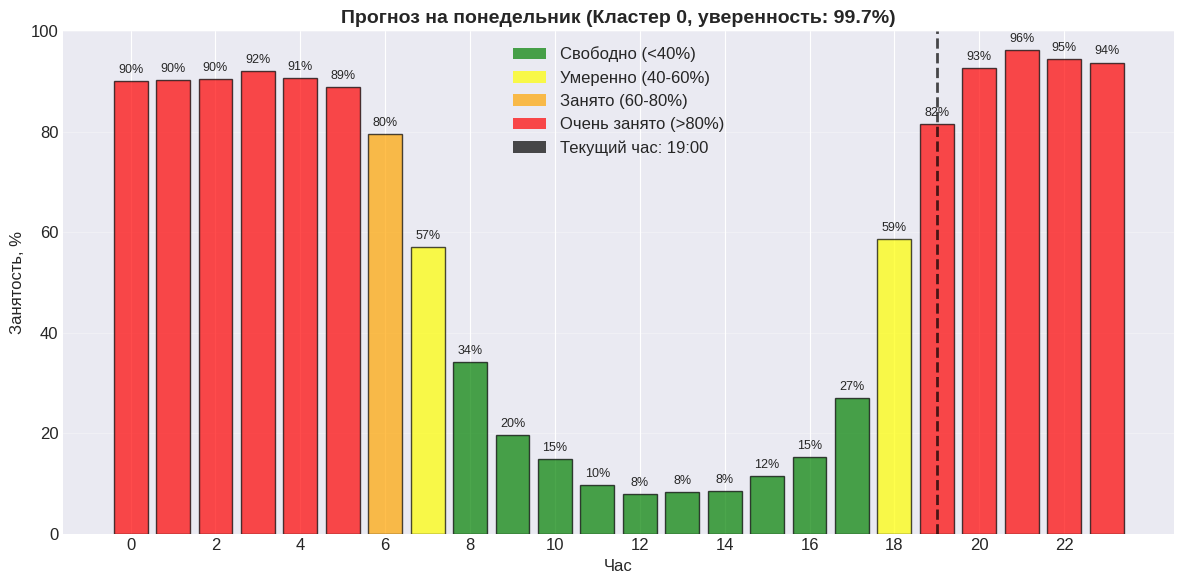


РЕКОМЕНДАЦИИ ПО ПАРКОВКЕ:
----------------------------------------
Сейчас (19:00): занятость 82%
🚨 ВЫСОКАЯ ЗАНЯТОСТЬ, рассмотрите другие варианты

Лучшие часы для парковки:
  • 12:00 - 8% занятости
  • 13:00 - 8% занятости
  • 14:00 - 8% занятости

ТЕСТ 2: ТИПИЧНЫЙ ВТОРНИК
{'day_of_week': 1, 'is_weekend': 0, 'is_holiday': 0, 'weather': 'облачно', 'temperature': 1.0}
Предсказанный кластер: 1
Уверенность: 98.6%
Средняя занятость: 65.9%
Пиковая занятость: 100% в 21:00


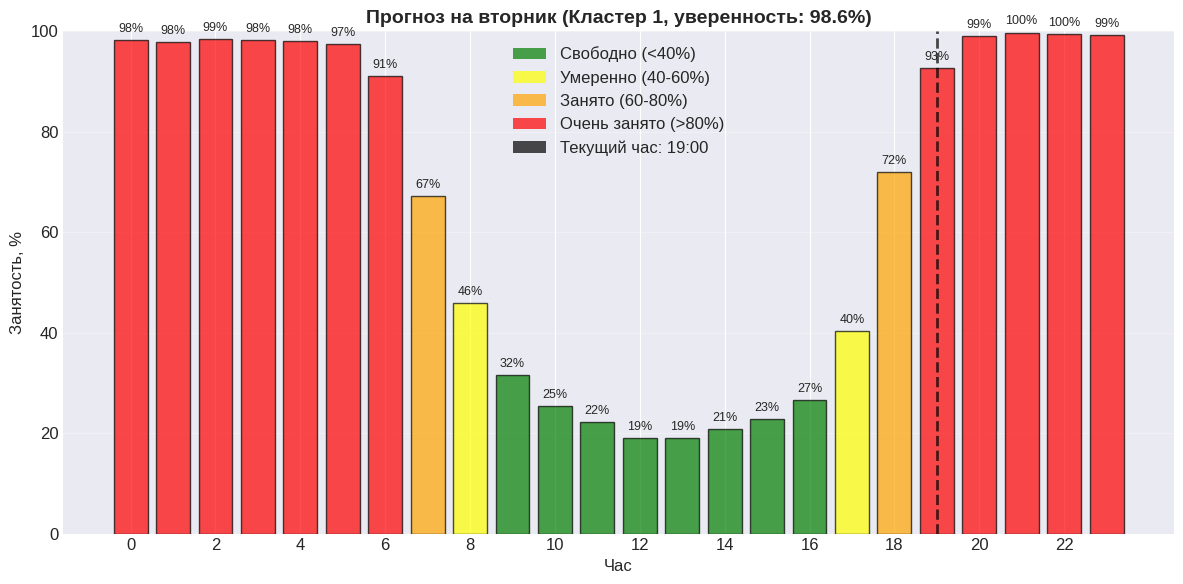


РЕКОМЕНДАЦИИ ПО ПАРКОВКЕ:
----------------------------------------
Сейчас (19:00): занятость 93%
🚨 ВЫСОКАЯ ЗАНЯТОСТЬ, рассмотрите другие варианты

Лучшие часы для парковки:
  • 13:00 - 19% занятости
  • 12:00 - 19% занятости
  • 14:00 - 21% занятости

ТЕСТ 3: ВОСКРЕСЕНЬЕ
{'day_of_week': 6, 'is_weekend': 1, 'is_holiday': 0, 'weather': 'облачно', 'temperature': 20.0}
Предсказанный кластер: 3
Уверенность: 90.0%
Средняя занятость: 75.0%
Пиковая занятость: 94% в 21:00


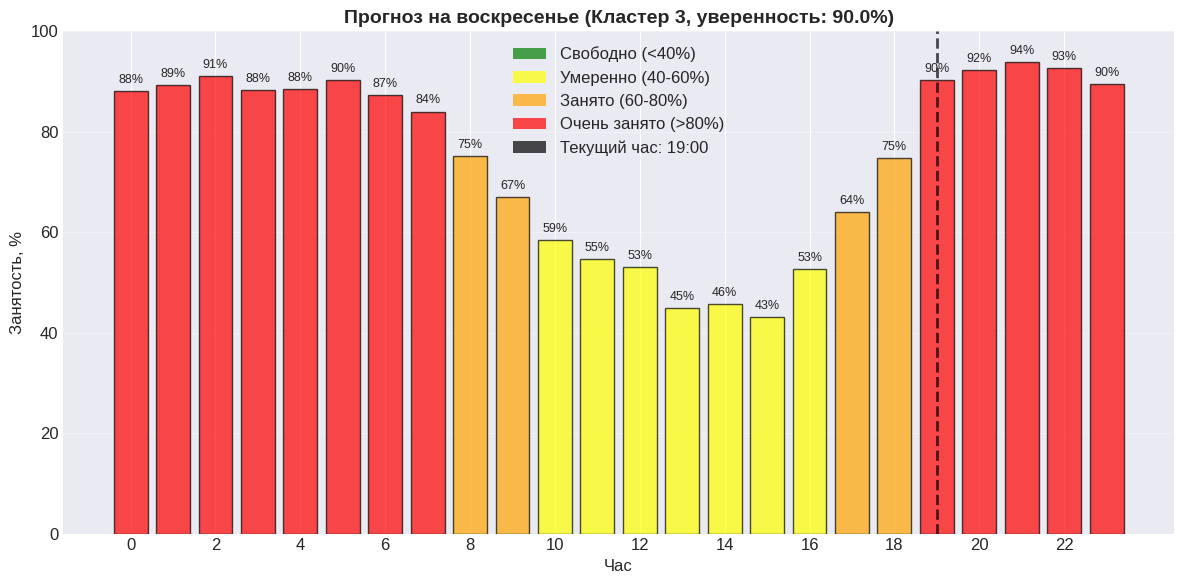


РЕКОМЕНДАЦИИ ПО ПАРКОВКЕ:
----------------------------------------
Сейчас (19:00): занятость 90%
🚨 ВЫСОКАЯ ЗАНЯТОСТЬ, рассмотрите другие варианты

Лучшие часы для парковки:
  • 15:00 - 43% занятости
  • 13:00 - 45% занятости
  • 14:00 - 46% занятости

ТЕСТ 4: СУББОТА
{'day_of_week': 5, 'is_weekend': 1, 'is_holiday': 1, 'weather': 'ясно', 'temperature': -2.1}
Предсказанный кластер: 2
Уверенность: 99.9%
Средняя занятость: 86.5%
Пиковая занятость: 99% в 20:00


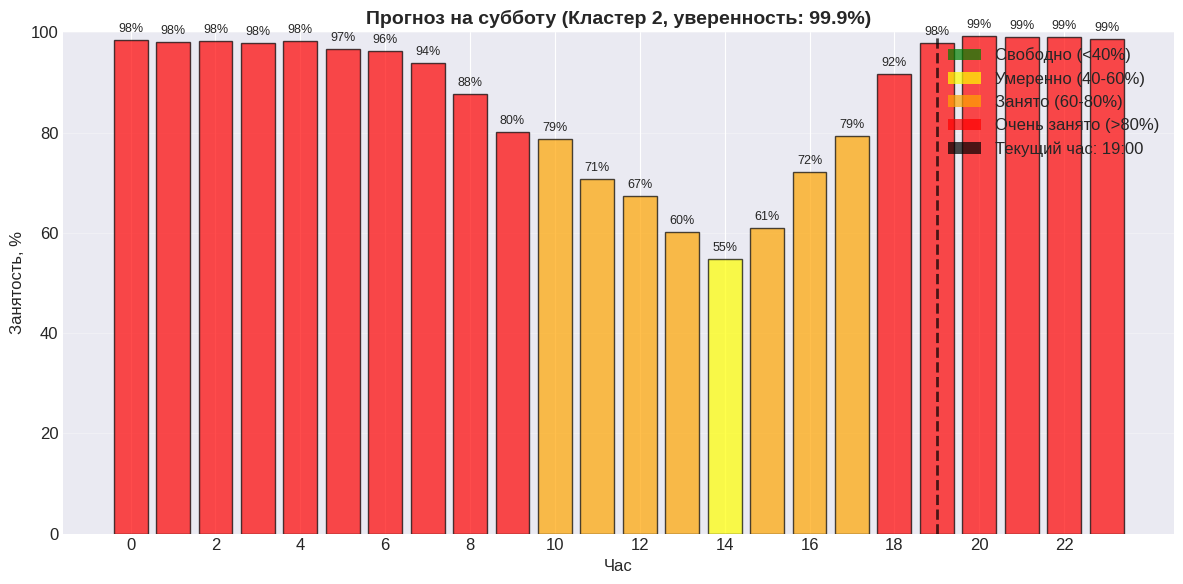


РЕКОМЕНДАЦИИ ПО ПАРКОВКЕ:
----------------------------------------
Сейчас (19:00): занятость 98%
🚨 ВЫСОКАЯ ЗАНЯТОСТЬ, рассмотрите другие варианты

Лучшие часы для парковки:
  • 14:00 - 55% занятости
  • 13:00 - 60% занятости
  • 15:00 - 61% занятости

ТЕСТИРОВАНИЕ ЗАВЕРШЕНО!

Созданы файлы прогнозов:
  1. test1_monday_prediction.png - прогноз на понедельник
  2. test2_tuesday_prediction.png - прогноз на вторник
  3. test3_sunday_prediction.png - прогноз на воскресенье
  4. test4_saturday_prediction.png - прогноз на субботу


In [43]:
# Ячейка 14: Создание системы тестирования и прогнозирования
print("СИСТЕМА ТЕСТИРОВАНИЯ И ПРОГНОЗИРОВАНИЯ ПО КЛАСТЕРАМ")
print("=" * 60)

class ParkingOccupancyPredictor:
    """Класс для прогнозирования занятости парковки на основе кластеров"""

    def __init__(self, clustered_data, centroids):
        """
        Инициализация предсказателя

        Parameters:
        clustered_data (pd.DataFrame): Кластеризованные данные с метаданными
        centroids (pd.DataFrame): Центроиды кластеров
        """
        self.clustered_data = clustered_data
        self.centroids = centroids
        self.cluster_rules = self._extract_cluster_rules()

    def _extract_cluster_rules(self):
        """Извлекает правила для определения кластера по метаданным"""
        cluster_rules = {}
        n_clusters = len(self.clustered_data['cluster'].unique())

        for cluster_id in range(n_clusters):
            cluster_data = self.clustered_data[self.clustered_data['cluster'] == cluster_id]

            # Вычисляем наиболее частые значения метаданных в кластере
            rules = {}

            # День недели
            if 'day_of_week' in cluster_data.columns:
                day_dist = cluster_data['day_of_week'].value_counts()
                if len(day_dist) > 0:
                    rules['typical_days'] = day_dist.head(3).index.tolist()  # Топ-3 дня

            # Погода
            if 'dominant_weather' in cluster_data.columns:
                weather_dist = cluster_data['dominant_weather'].value_counts()
                if len(weather_dist) > 0:
                    rules['typical_weather'] = weather_dist.head(3).index.tolist()

            # Тип дня
            if 'is_weekend' in cluster_data.columns:
                rules['weekend_percentage'] = cluster_data['is_weekend'].mean()

            if 'is_holiday' in cluster_data.columns:
                rules['holiday_percentage'] = cluster_data['is_holiday'].mean()

            # Температура
            if 'avg_temperature' in cluster_data.columns:
                temp_data = cluster_data['avg_temperature'].dropna()
                if len(temp_data) > 0:
                    rules['avg_temp_range'] = (temp_data.min(), temp_data.mean(), temp_data.max())

            cluster_rules[cluster_id] = rules

        return cluster_rules

    def predict_cluster_for_day(self, day_metadata):
        """
        Предсказывает наиболее подходящий кластер для заданного дня

        Parameters:
        day_metadata (dict): Метаданные дня:
            - day_of_week: int (0-6, 0=пн, 6=вс)
            - is_weekend: int (0 или 1)
            - is_holiday: int (0 или 1)
            - weather: str (тип погоды)
            - temperature: float (средняя температура)

        Returns:
        int: Номер предсказанного кластера
        float: Уверенность предсказания (0-1)
        """
        scores = []
        n_clusters = len(self.cluster_rules)

        for cluster_id in range(n_clusters):
            rules = self.cluster_rules[cluster_id]
            score = 0
            max_score = 0

            # 1. Проверка дня недели (вес: 40%)
            if 'typical_days' in rules and 'day_of_week' in day_metadata:
                if day_metadata['day_of_week'] in rules['typical_days']:
                    score += 0.4
                max_score += 0.4

            # 2. Проверка погоды (вес: 30%)
            if 'typical_weather' in rules and 'weather' in day_metadata:
                if day_metadata['weather'] in rules['typical_weather']:
                    score += 0.3
                max_score += 0.3

            # 3. Проверка типа дня (выходной/праздник) (вес: 20%)
            if 'weekend_percentage' in rules and 'is_weekend' in day_metadata:
                if (day_metadata['is_weekend'] == 1 and rules['weekend_percentage'] > 0.5) or \
                   (day_metadata['is_weekend'] == 0 and rules['weekend_percentage'] < 0.5):
                    score += 0.1
                max_score += 0.1

            if 'holiday_percentage' in rules and 'is_holiday' in day_metadata:
                if (day_metadata['is_holiday'] == 1 and rules['holiday_percentage'] > 0.1) or \
                   (day_metadata['is_holiday'] == 0 and rules['holiday_percentage'] < 0.1):
                    score += 0.1
                max_score += 0.1

            # 4. Проверка температуры (вес: 10%)
            if 'avg_temp_range' in rules and 'temperature' in day_metadata:
                temp_min, temp_mean, temp_max = rules['avg_temp_range']
                if temp_min <= day_metadata['temperature'] <= temp_max:
                    # Близость к среднему значению кластера
                    temp_diff = abs(day_metadata['temperature'] - temp_mean)
                    temp_score = max(0, 1 - temp_diff / 20)  # Нормализация
                    score += temp_score * 0.1
                max_score += 0.1

            # Нормализуем score
            normalized_score = score / max_score if max_score > 0 else 0
            scores.append((cluster_id, normalized_score))

        # Выбираем кластер с максимальным score
        best_cluster, best_score = max(scores, key=lambda x: x[1])

        return best_cluster, best_score

    def get_occupancy_profile(self, cluster_id):
        """
        Возвращает профиль занятости для заданного кластера

        Parameters:
        cluster_id (int): Номер кластера

        Returns:
        np.array: Профиль занятости из 24 значений
        """
        if cluster_id in self.centroids['cluster'].values:
            cluster_centroid = self.centroids[self.centroids['cluster'] == cluster_id]
            hour_cols = [f'hour_{h:02d}' for h in range(24)]
            profile = cluster_centroid[hour_cols].values[0]
            return profile
        else:
            raise ValueError(f"Кластер {cluster_id} не найден")

    def predict_occupancy_for_day(self, day_metadata):
        """
        Полный прогноз занятости для заданного дня

        Parameters:
        day_metadata (dict): Метаданные дня

        Returns:
        dict: Результаты прогноза
        """
        cluster_id, confidence = self.predict_cluster_for_day(day_metadata)
        profile = self.get_occupancy_profile(cluster_id)

        return {
            'predicted_cluster': cluster_id,
            'confidence': confidence,
            'occupancy_profile': profile,
            'peak_hour': int(np.argmax(profile)),
            'peak_value': float(np.max(profile)),
            'min_hour': int(np.argmin(profile)),
            'min_value': float(np.min(profile)),
            'avg_occupancy': float(np.mean(profile))
        }

def plot_occupancy_histogram(occupancy_profile, title="Прогноз занятости парковки",
                            save_path=None):
    """
    Визуализация гистограммы занятости

    Parameters:
    occupancy_profile (np.array): Массив из 24 значений занятости
    title (str): Заголовок графика
    save_path (str): Путь для сохранения графика
    """
    fig, ax = plt.subplots(figsize=(12, 6))

    # Цвета столбцов в зависимости от занятости
    colors = []
    for value in occupancy_profile:
        if value > 80:
            colors.append('red')
        elif value > 60:
            colors.append('orange')
        elif value > 40:
            colors.append('yellow')
        else:
            colors.append('green')

    bars = ax.bar(range(24), occupancy_profile, color=colors, alpha=0.7, edgecolor='black')

    # Добавляем значения на столбцы
    for i, (bar, value) in enumerate(zip(bars, occupancy_profile)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{value:.0f}%', ha='center', va='bottom', fontsize=9)

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Час', fontsize=12)
    ax.set_ylabel('Занятость, %', fontsize=12)
    ax.set_xticks(range(0, 24, 2))
    ax.set_ylim(0, 100)
    ax.grid(True, alpha=0.3, axis='y')

    # Добавляем легенду
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='green', alpha=0.7, label='Свободно (<40%)'),
        Patch(facecolor='yellow', alpha=0.7, label='Умеренно (40-60%)'),
        Patch(facecolor='orange', alpha=0.7, label='Занято (60-80%)'),
        Patch(facecolor='red', alpha=0.7, label='Очень занято (>80%)')
    ]
    ax.legend(handles=legend_elements, loc='upper right')

    # Добавляем текущий час (если известно)
    from datetime import datetime
    current_hour = datetime.now().hour
    ax.axvline(x=current_hour, color='black', linestyle='--', linewidth=2,
               alpha=0.7, label=f'Текущий час: {current_hour}:00')
    ax.legend(handles=legend_elements + [Patch(facecolor='black', alpha=0.7,
                                               label=f'Текущий час: {current_hour}:00')])

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()

    # Выводим рекомендации
    print("\nРЕКОМЕНДАЦИИ ПО ПАРКОВКЕ:")
    print("-" * 40)

    current_hour = datetime.now().hour
    if current_hour < 24:
        current_occupancy = occupancy_profile[current_hour]
        print(f"Сейчас ({current_hour}:00): занятость {current_occupancy:.0f}%")

        if current_occupancy < 40:
            print("🎯 ОТЛИЧНОЕ ВРЕМЯ ДЛЯ ПАРКОВКИ!")
        elif current_occupancy < 70:
            print("⚠️  СРЕДНЯЯ ЗАНЯТОСТЬ, можно попробовать")
        else:
            print("🚨 ВЫСОКАЯ ЗАНЯТОСТЬ, рассмотрите другие варианты")

    # Лучшие часы для парковки
    best_hours = np.argsort(occupancy_profile)[:3]  # 3 часа с минимальной занятостью
    print(f"\nЛучшие часы для парковки:")
    for hour in best_hours:
        print(f"  • {hour}:00 - {occupancy_profile[hour]:.0f}% занятости")

# Инициализируем предсказатель
print("Инициализация предсказателя...")
predictor = ParkingOccupancyPredictor(clustered_days, centroids_df)

# Тест 1: Типичный понедельник (Кластер 0)
print("\n" + "="*60)
print("ТЕСТ 1: ТИПИЧНЫЙ ПОНЕДЕЛЬНИК")
print("="*60)

test1_metadata = {
    'day_of_week': 0,      # Понедельник
    'is_weekend': 0,       # Не выходной
    'is_holiday': 0,       # Не праздник
    'weather': 'ясно',     # Ясная погода
    'temperature': 15.0    # Средняя температура
}
print(test1_metadata)

result1 = predictor.predict_occupancy_for_day(test1_metadata)
print(f"Предсказанный кластер: {result1['predicted_cluster']}")
print(f"Уверенность: {result1['confidence']:.1%}")
print(f"Средняя занятость: {result1['avg_occupancy']:.1f}%")
print(f"Пиковая занятость: {result1['peak_value']:.0f}% в {result1['peak_hour']}:00")

plot_occupancy_histogram(
    result1['occupancy_profile'],
    title=f"Прогноз на понедельник (Кластер {result1['predicted_cluster']}, уверенность: {result1['confidence']:.1%})",
    save_path='test1_monday_prediction.png'
)

# Тест 2: Типичный вторник (Кластер 1)
print("\n" + "="*60)
print("ТЕСТ 2: ТИПИЧНЫЙ ВТОРНИК")
print("="*60)

test2_metadata = {
    'day_of_week': 1,      # Вторник
    'is_weekend': 0,       # Не выходной
    'is_holiday': 0,       # Не праздник
    'weather': 'облачно',  # Облачная погода
    'temperature': 1.0     # Средняя температура
}
print(test2_metadata)

result2 = predictor.predict_occupancy_for_day(test2_metadata)
print(f"Предсказанный кластер: {result2['predicted_cluster']}")
print(f"Уверенность: {result2['confidence']:.1%}")
print(f"Средняя занятость: {result2['avg_occupancy']:.1f}%")
print(f"Пиковая занятость: {result2['peak_value']:.0f}% в {result2['peak_hour']}:00")

plot_occupancy_histogram(
    result2['occupancy_profile'],
    title=f"Прогноз на вторник (Кластер {result2['predicted_cluster']}, уверенность: {result2['confidence']:.1%})",
    save_path='test2_tuesday_prediction.png'
)

# Тест 3: Воскресенье (Кластер 2)
print("\n" + "="*60)
print("ТЕСТ 3: ВОСКРЕСЕНЬЕ")
print("="*60)

test3_metadata = {
    'day_of_week': 6,      # Воскресенье
    'is_weekend': 1,       # Выходной
    'is_holiday': 0,       # Не праздник (обычное воскресенье)
    'weather': 'облачно',  # Облачная погода
    'temperature': 20.0    # Средняя температура
}
print(test3_metadata)

result3 = predictor.predict_occupancy_for_day(test3_metadata)
print(f"Предсказанный кластер: {result3['predicted_cluster']}")
print(f"Уверенность: {result3['confidence']:.1%}")
print(f"Средняя занятость: {result3['avg_occupancy']:.1f}%")
print(f"Пиковая занятость: {result3['peak_value']:.0f}% в {result3['peak_hour']}:00")

plot_occupancy_histogram(
    result3['occupancy_profile'],
    title=f"Прогноз на воскресенье (Кластер {result3['predicted_cluster']}, уверенность: {result3['confidence']:.1%})",
    save_path='test3_sunday_prediction.png'
)

# Тест 4: Суббота (Кластер 3)
print("\n" + "="*60)
print("ТЕСТ 4: СУББОТА")
print("="*60)

test4_metadata = {
    'day_of_week': 5,      # Суббота
    'is_weekend': 1,       # Выходной
    'is_holiday': 1,       # Не праздник
    'weather': 'ясно',     # Ясная погода
    'temperature': -2.1     # Средняя температура
}
print(test4_metadata)

result4 = predictor.predict_occupancy_for_day(test4_metadata)
print(f"Предсказанный кластер: {result4['predicted_cluster']}")
print(f"Уверенность: {result4['confidence']:.1%}")
print(f"Средняя занятость: {result4['avg_occupancy']:.1f}%")
print(f"Пиковая занятость: {result4['peak_value']:.0f}% в {result4['peak_hour']}:00")

plot_occupancy_histogram(
    result4['occupancy_profile'],
    title=f"Прогноз на субботу (Кластер {result4['predicted_cluster']}, уверенность: {result4['confidence']:.1%})",
    save_path='test4_saturday_prediction.png'
)


# Создаем функцию для интерактивного тестирования
def interactive_prediction_test():
    """Интерактивная функция для тестирования прогнозов"""
    print("\n" + "="*60)
    print("ИНТЕРАКТИВНЫЙ ТЕСТ ПРОГНОЗИРОВАНИЯ")
    print("="*60)

    # Спрашиваем параметры у пользователя
    print("\nВведите параметры дня для прогноза:")

    day_names = ['понедельник', 'вторник', 'среда', 'четверг', 'пятница', 'суббота', 'воскресенье']
    for i, name in enumerate(day_names):
        print(f"  {i}: {name}")

    day_of_week = int(input("\nДень недели (0-6): "))

    is_weekend = int(input("Выходной? (0-нет, 1-да): "))
    is_holiday = int(input("Праздник? (0-нет, 1-да): "))

    print("\nТипы погоды: ясно, облачно, дождь, снег, туман")
    weather = input("Погода: ")

    temperature = float(input("Средняя температура (°C): "))

    # Формируем метаданные
    metadata = {
        'day_of_week': day_of_week,
        'is_weekend': is_weekend,
        'is_holiday': is_holiday,
        'weather': weather,
        'temperature': temperature
    }

    # Делаем предсказание
    result = predictor.predict_occupancy_for_day(metadata)

    print(f"\nРЕЗУЛЬТАТЫ ПРОГНОЗА:")
    print(f"• Предсказанный кластер: {result['predicted_cluster']}")
    print(f"• Уверенность предсказания: {result['confidence']:.1%}")
    print(f"• Средняя занятость за день: {result['avg_occupancy']:.1f}%")
    print(f"• Пиковая занятость: {result['peak_value']:.0f}% в {result['peak_hour']}:00")
    print(f"• Минимальная занятость: {result['min_value']:.0f}% в {result['min_hour']}:00")

    # Строим гистограмму
    plot_occupancy_histogram(
        result['occupancy_profile'],
        title=f"Прогноз на {day_names[day_of_week]} (Кластер {result['predicted_cluster']})"
    )

    return result

# interactive_prediction_test()  # Интерактивный тест :)

print("\n" + "="*60)
print("ТЕСТИРОВАНИЕ ЗАВЕРШЕНО!")
print("="*60)
print("\nСозданы файлы прогнозов:")
print("  1. test1_monday_prediction.png - прогноз на понедельник")
print("  2. test2_tuesday_prediction.png - прогноз на вторник")
print("  3. test3_sunday_prediction.png - прогноз на воскресенье")
print("  4. test4_saturday_prediction.png - прогноз на субботу")